# From Data to Symmetry
## Sparse discovery of a relativistic field equation and its Noether charges

**Advanced Topics in Physics of Data — final project**

> **Research question.** Can sparse data-driven methods recover both a nonlinear relativistic field equation and its Noether conservation laws from noisy, sparsely sampled field measurements?

I developed a complete, reproducible experiment around the nonlinear Klein–Gordon (or $\phi^4$) field. It does not merely fit a black-box predictor: it attempts to recover an interpretable differential equation and conserved physical quantities.

### Main contributions

1. Generate high-quality field trajectories with a Fourier pseudospectral, symplectic solver.
2. Recover the governing PDE using sparse identification from a deliberately over-complete library.
3. Compare a derivative-based **strong formulation** with a noise-robust **weak formulation**.
4. Discover energy and momentum directly from field trajectories through a sparse null-space method.
5. Quantify equation support, coefficient error, rollout error and conservation drift under noise.
6. Test for an **inverse crime** using data generated by an independent finite-difference/adaptive-Runge–Kutta solver and passed through a realistic sensor model.

All random seeds, numerical parameters and evaluation rules are fixed below for reproducibility.

## 1. Physical model and Noether structure

We study a real scalar field $\phi(x,t)$ on a periodic one-dimensional domain. In nondimensional units its Lagrangian density is

$$
\mathcal L = \frac{1}{2}\phi_t^2-\frac{c^2}{2}\phi_x^2
-\frac{m^2}{2}\phi^2-\frac{\lambda}{4}\phi^4.
$$

The Euler–Lagrange equation is the nonlinear Klein–Gordon equation

$$
\boxed{\phi_{tt}=c^2\phi_{xx}-m^2\phi-\lambda\phi^3.}
$$

Time-translation and space-translation invariance imply two Noether charges:

$$
E=\int\left(\frac12\phi_t^2+\frac{c^2}{2}\phi_x^2
+\frac{m^2}{2}\phi^2+\frac{\lambda}{4}\phi^4\right)dx,
\qquad
P=-\int \phi_t\phi_x\,dx.
$$

Importantly, the discovery algorithms below are **not given these final expressions**. They receive a candidate library containing correct and incorrect terms and must select a sparse combination.

## 2. Identification strategy

For PDE discovery we assume only that the dynamics are autonomous, local, polynomial in $\phi$ up to degree five, and contain spatial derivatives up to second order:

$$
\phi_{tt}=\Theta(\phi)\,\xi,
\qquad
\Theta=[1,\phi,\phi^2,\phi^3,\phi^5,\phi_x,\phi_{xx}].
$$

Sequentially thresholded least squares (STLSQ) estimates a sparse coefficient vector $\xi$.

The strong formulation estimates derivatives pointwise. The weak formulation multiplies the PDE by compact test functions $\psi$ and integrates by parts:

$$
\iint \phi\,\psi_{tt}\,dxdt
=c^2\iint\phi\,\psi_{xx}\,dxdt
-m^2\iint\phi\psi\,dxdt
-\lambda\iint\phi^3\psi\,dxdt.
$$

Thus the weak method differentiates smooth test functions instead of noisy observations.

In [23]:
from pathlib import Path
import itertools
import platform
import sys
import time
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysindy as ps
from IPython.display import Markdown, display
from scipy.integrate import solve_ivp
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter
from scipy.stats import t as student_t

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Reproducibility 
SEED = 314159
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

COLORS = {
    "ink": "#202936",
    "blue": "#2E6FBB",
    "cyan": "#2589A6",
    "orange": "#C46A00",
    "gold": "#B98700",
    "green": "#16836B",
    "teal": "#1B7F79",
    "red": "#C83E3E",
    "purple": "#7046C9",
    "gray": "#6B7280",
    "paper": "#FFFFFF",
}
mpl.rcParams.update({
    "figure.figsize": (9.0, 5.2),
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "medium",
    "axes.titlepad": 10,
    "axes.labelpad": 6,
    "axes.edgecolor": "#D1D5DB",
    "axes.linewidth": 0.7,
    "axes.axisbelow": True,
    "axes.labelsize": 9.8,
    "axes.titlesize": 11.5,
    "xtick.labelsize": 9.2,
    "ytick.labelsize": 9.2,
    "legend.frameon": False,
    "legend.fontsize": 8.6,
    "legend.handlelength": 1.8,
    "grid.color": "#E5E7EB",
    "grid.alpha": 0.52,
    "grid.linewidth": 0.55,
    "font.family": "DejaVu Sans",
    "font.size": 9.8,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "mathtext.fontset": "stix",
})

FIG_DIR = Path("advanced_topics_figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, facecolor="white")
    plt.savefig(path.with_suffix(".pdf"), facecolor="white")

def ci95_from_std(std, n):
    # Two-sided Student-t 95% confidence half-width.
    std = np.asarray(std, dtype=float)
    n = np.asarray(n, dtype=float)
    critical = student_t.ppf(0.975, np.maximum(n-1, 1))
    return np.where(n < 2, 0.0, critical * std / np.sqrt(n))

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | {platform.system()}")

Python 3.11.14 | NumPy 2.4.2 | Darwin


## 3. Numerical experiment

We use periodic boundaries, Fourier derivatives and velocity Verlet time stepping. Velocity Verlet is symplectic for the semi-discrete Hamiltonian system and therefore avoids artificial secular energy drift.

Multiple smooth random initial conditions are essential: a single trajectory can make physically different library terms highly correlated and therefore non-identifiable.

In [24]:
# Ground-truth physical and numerical parameters
C = 1.0
MASS = 1.0
LAMBDA = 1.0
LENGTH = 20.0
NX = 192
DX = LENGTH / NX
DT_SOLVER = 0.01
T_FINAL = 12.0
SAVE_EVERY = 5
DT_OBS = DT_SOLVER * SAVE_EVERY

x = np.linspace(-LENGTH / 2, LENGTH / 2, NX, endpoint=False)
t_obs = np.arange(0.0, T_FINAL + 0.5 * DT_OBS, DT_OBS)
wave_numbers = 2 * np.pi * np.fft.fftfreq(NX, d=DX)

PDE_TERMS = ["1", "phi", "phi^2", "phi^3", "phi^5", "phi_x", "phi_xx"]
PDE_LABELS = [r"$1$", r"$\phi$", r"$\phi^2$", r"$\phi^3$",
              r"$\phi^5$", r"$\phi_x$", r"$\phi_{xx}$"]
TRUE_PDE_COEF = np.array([0.0, -MASS**2, 0.0, -LAMBDA, 0.0, 0.0, C**2])

def spectral_derivative(field, order=1):
    # Periodic Fourier derivative along the last axis.
    multiplier = (1j * wave_numbers) ** order
    return np.fft.ifft(np.fft.fft(field, axis=-1) * multiplier, axis=-1).real

def true_acceleration(phi):
    return C**2 * spectral_derivative(phi, 2) - MASS**2 * phi - LAMBDA * phi**3

def library_acceleration(phi, coefficients):
    # Evaluate the complete learned candidate library for rollout validation.
    phi_x = spectral_derivative(phi, 1)
    phi_xx = spectral_derivative(phi, 2)
    fields = [np.ones_like(phi), phi, phi**2, phi**3, phi**5, phi_x, phi_xx]
    return sum(a * f for a, f in zip(coefficients, fields))

def make_initial_condition(seed, rms_phi=0.68, rms_pi=0.28, n_modes=6):
    local_rng = np.random.default_rng(seed)
    raw_phi = np.zeros_like(x)
    raw_pi = np.zeros_like(x)
    for k in range(1, n_modes + 1):
        scale = k ** -1.45
        raw_phi += scale * local_rng.normal() * np.cos(2*np.pi*k*x/LENGTH + local_rng.uniform(0, 2*np.pi))
        raw_pi += scale * local_rng.normal() * np.sin(2*np.pi*k*x/LENGTH + local_rng.uniform(0, 2*np.pi))
    raw_phi -= raw_phi.mean()
    raw_pi -= raw_pi.mean()
    raw_phi *= rms_phi / np.sqrt(np.mean(raw_phi**2))
    # Mix a traveling-wave component into pi so momentum is nonzero and
    # its relative conservation error remains a meaningful diagnostic.
    random_pi = raw_pi / np.sqrt(np.mean(raw_pi**2))
    traveling_pi = -spectral_derivative(raw_phi, 1)
    traveling_pi /= np.sqrt(np.mean(traveling_pi**2))
    raw_pi = 0.65*random_pi + 0.75*traveling_pi
    raw_pi -= raw_pi.mean()
    raw_pi *= rms_pi / np.sqrt(np.mean(raw_pi**2))
    return raw_phi, raw_pi

def simulate(phi0, pi0, acceleration=true_acceleration):
    # Velocity-Verlet integration; returns observations at DT_OBS.
    n_steps = int(round(T_FINAL / DT_SOLVER))
    phi = phi0.copy()
    pi = pi0.copy()
    phi_history = [phi.copy()]
    pi_history = [pi.copy()]
    for step in range(1, n_steps + 1):
        pi_half = pi + 0.5 * DT_SOLVER * acceleration(phi)
        phi = phi + DT_SOLVER * pi_half
        pi = pi_half + 0.5 * DT_SOLVER * acceleration(phi)
        if step % SAVE_EVERY == 0:
            phi_history.append(phi.copy())
            pi_history.append(pi.copy())
    return np.asarray(phi_history), np.asarray(pi_history)

def energy_and_momentum(phi, pi):
    phi_x = spectral_derivative(phi, 1)
    energy_density = (0.5*pi**2 + 0.5*C**2*phi_x**2
                      + 0.5*MASS**2*phi**2 + 0.25*LAMBDA*phi**4)
    energy = DX * np.sum(energy_density, axis=-1)
    momentum = -DX * np.sum(pi * phi_x, axis=-1)
    return energy, momentum

start = time.perf_counter()
trajectories = []
for seed in range(8):
    phi0, pi0 = make_initial_condition(SEED + seed)
    phi_hist, pi_hist = simulate(phi0, pi0)
    trajectories.append((phi_hist, pi_hist))

phi_all = np.stack([item[0] for item in trajectories])
pi_all = np.stack([item[1] for item in trajectories])
phi_train, pi_train = phi_all[:6], pi_all[:6]
phi_test, pi_test = phi_all[6:], pi_all[6:]
print(f"Generated {len(phi_all)} trajectories with shape {phi_all.shape} in {time.perf_counter()-start:.2f} s")
print(f"Training trajectories: 6 (five fit + one validation); held-out trajectories: 2")

Generated 8 trajectories with shape (8, 241, 192) in 0.29 s
Training trajectories: 6 (five fit + one validation); held-out trajectories: 2


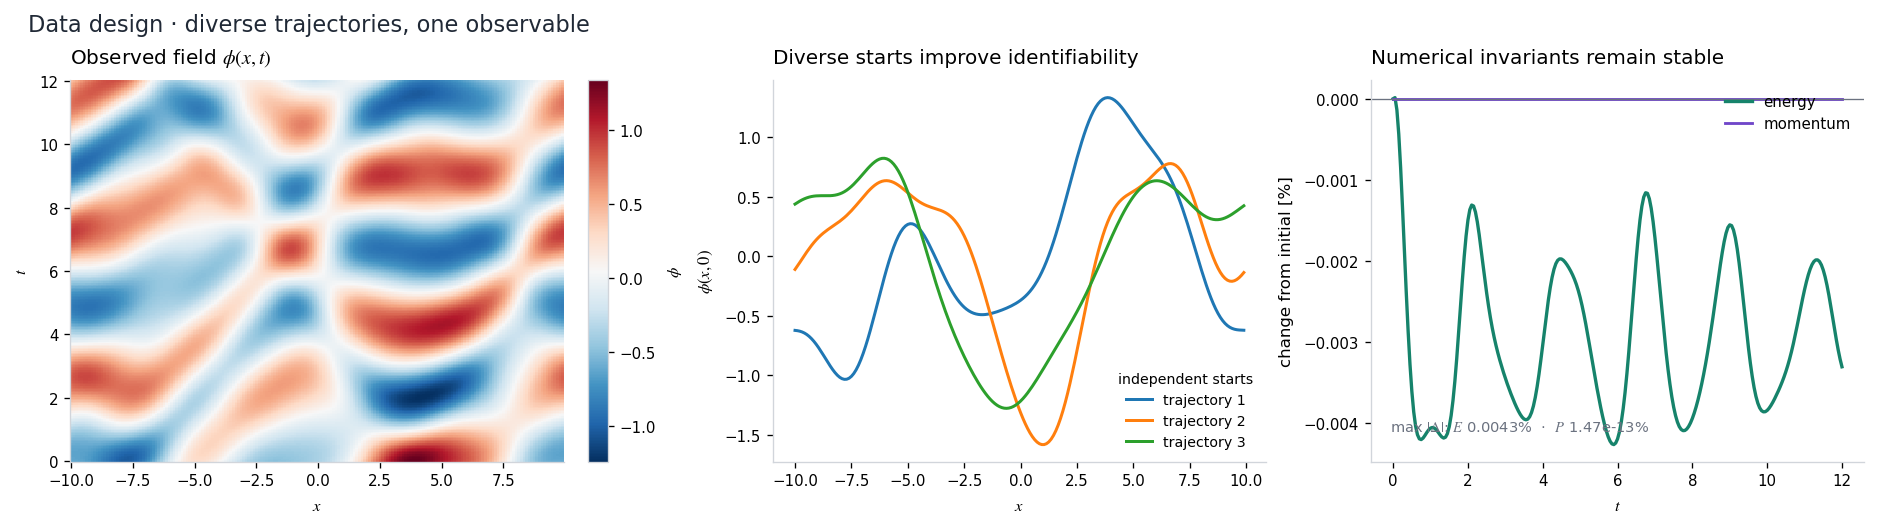

,diagnostic,value
0,maximum relative energy drift,4.262e-05
1,maximum relative momentum drift,1.469e-15


In [26]:
# Solver quality control 
energy0, momentum0 = energy_and_momentum(phi_all[0], pi_all[0])
rel_energy_drift = np.max(np.abs(energy0 / energy0[0] - 1))
momentum_scale = max(np.max(np.abs(momentum0)), 1e-12)
rel_momentum_drift = np.max(np.abs(momentum0 - momentum0[0])) / momentum_scale

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.25), constrained_layout=True)
fig.suptitle("Data design · diverse trajectories, one observable",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
im = axes[0].pcolormesh(x, t_obs, phi_all[0], shading="auto", cmap="RdBu_r")
axes[0].set(title=r"Observed field $\phi(x,t)$", xlabel="$x$", ylabel="$t$")
fig.colorbar(im, ax=axes[0], label="$\phi$")

for j in range(3):
    axes[1].plot(x, phi_all[j, 0], lw=1.8, label=f"trajectory {j+1}")
axes[1].set(title="Diverse starts improve identifiability", xlabel="$x$", ylabel=r"$\phi(x,0)$")
axes[1].legend(title="independent starts", fontsize=8.5, title_fontsize=8.5)

axes[2].plot(t_obs, 100*(energy0 / energy0[0] - 1), color=COLORS["green"], lw=2, label="energy")
axes[2].plot(t_obs, 100*(momentum0 - momentum0[0]) / momentum_scale,
             color=COLORS["purple"], lw=1.7, label="momentum")
axes[2].axhline(0, color=COLORS["gray"], lw=0.8)
axes[2].set(title="Numerical invariants remain stable", xlabel="$t$", ylabel="change from initial [%]")
axes[2].text(0.04, 0.08,
             rf"max $|\Delta|$: $E$ {100*rel_energy_drift:.4f}%  ·  $P$ {100*rel_momentum_drift:.2e}%",
             transform=axes[2].transAxes, color=COLORS["gray"], fontsize=8.8)
axes[2].legend(loc="upper right", fontsize=9)
for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("01_dataset_and_solver_validation.png")
plt.show()

display(pd.DataFrame({
    "diagnostic": ["maximum relative energy drift", "maximum relative momentum drift"],
    "value": [rel_energy_drift, rel_momentum_drift],
}).style.format({"value": "{:.3e}"}))

**Interpretation.** The trajectories visibly explore different regions of state space while the numerical invariants remain nearly constant. This is crucial: the learning algorithm should be evaluated against physical dynamics, not artifacts of an inaccurate simulator.

## 4. Sparse PDE discovery: strong formulation

The strong method estimates $\phi_{tt}$, $\phi_x$ and $\phi_{xx}$ with local polynomial filters, constructs the candidate matrix pointwise and applies STLSQ. Model selection is performed on an entire held-out trajectory, not random points from the training trajectories.

In [29]:
def stlsq(A, b, threshold, max_iter=25):
    # Sequentially thresholded least squares with column and target scaling.
    column_scale = np.linalg.norm(A, axis=0)
    column_scale[column_scale < 1e-14] = 1.0
    target_scale = max(np.linalg.norm(b), 1e-14)
    An = A / column_scale
    bn = b / target_scale
    coef_n = np.linalg.lstsq(An, bn, rcond=None)[0]
    active_previous = None
    for _ in range(max_iter):
        active = np.abs(coef_n) >= threshold
        if not np.any(active):
            active[np.argmax(np.abs(coef_n))] = True
        if active_previous is not None and np.array_equal(active, active_previous):
            break
        active_previous = active.copy()
        coef_n[~active] = 0.0
        coef_n[active] = np.linalg.lstsq(An[:, active], bn, rcond=None)[0]
    return target_scale * coef_n / column_scale

THRESHOLDS = np.r_[0.0, np.logspace(-4.0, -0.15, 24)]

def fit_sparse_path(A_fit, b_fit, A_val, b_val, tolerance=0.05):
    # Choose the sparsest model within tolerance of the best validation error.
    candidates = []
    variance = max(np.mean((b_val - b_val.mean())**2), 1e-14)
    for threshold in THRESHOLDS:
        coef = stlsq(A_fit, b_fit, threshold)
        val_nmse = np.mean((A_val @ coef - b_val)**2) / variance
        support = int(np.count_nonzero(np.abs(coef) > 1e-10))
        candidates.append((threshold, coef, val_nmse, support))
    min_error = min(row[2] for row in candidates)
    eligible = [row for row in candidates if row[2] <= (1+tolerance)*min_error + 1e-12]
    best = sorted(eligible, key=lambda row: (row[3], row[2]))[0]
    return best, pd.DataFrame({
        "threshold": [r[0] for r in candidates],
        "validation_NMSE": [r[2] for r in candidates],
        "support_size": [r[3] for r in candidates],
    })

def strong_library(phi_observed, max_rows=80_000, seed=0):
    # Pointwise library using Savitzky–Golay smoothing and derivatives.
    wt, wx = 17, 13
    phi_t_smooth = savgol_filter(phi_observed, wt, 5, axis=1, mode="interp")
    phi_smooth = savgol_filter(phi_t_smooth, wx, 5, axis=2, mode="wrap")
    phi_tt = savgol_filter(phi_smooth, wt, 5, deriv=2, delta=DT_OBS, axis=1, mode="interp")
    phi_x = savgol_filter(phi_smooth, wx, 5, deriv=1, delta=DX, axis=2, mode="wrap")
    phi_xx = savgol_filter(phi_smooth, wx, 5, deriv=2, delta=DX, axis=2, mode="wrap")
    pad = wt // 2
    u = phi_smooth[:, pad:-pad]
    fields = [np.ones_like(u), u, u**2, u**3, u**5,
              phi_x[:, pad:-pad], phi_xx[:, pad:-pad]]
    A = np.column_stack([f.reshape(-1) for f in fields])
    b = phi_tt[:, pad:-pad].reshape(-1)
    if len(b) > max_rows:
        local_rng = np.random.default_rng(seed)
        keep = local_rng.choice(len(b), max_rows, replace=False)
        A, b = A[keep], b[keep]
    return A, b

def support_f1(coef, truth=TRUE_PDE_COEF, cutoff=0.08):
    pred = np.abs(coef) >= cutoff
    actual = np.abs(truth) > 0
    tp = np.sum(pred & actual)
    fp = np.sum(pred & ~actual)
    fn = np.sum(~pred & actual)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return 2*precision*recall / max(precision + recall, 1e-14)

def coefficient_error(coef, truth=TRUE_PDE_COEF):
    return np.linalg.norm(coef - truth) / np.linalg.norm(truth)

def format_equation(coef, cutoff=0.03):
    pieces = []
    for value, term in zip(coef, PDE_TERMS):
        if abs(value) >= cutoff:
            pieces.append(f"{value:+.4f} {term}")
    return "phi_tt = " + " ".join(pieces).lstrip("+")

A_fit_s, b_fit_s = strong_library(phi_train[:5], seed=SEED)
A_val_s, b_val_s = strong_library(phi_train[5:6], max_rows=35_000, seed=SEED+1)
strong_best, strong_path = fit_sparse_path(A_fit_s, b_fit_s, A_val_s, b_val_s)
strong_threshold, strong_clean_coef, strong_val_nmse, _ = strong_best

print("Ground truth: ", format_equation(TRUE_PDE_COEF))
print("Strong form:  ", format_equation(strong_clean_coef))
print(f"Selected threshold={strong_threshold:.3g}; validation NMSE={strong_val_nmse:.3e}")

Ground truth:  phi_tt = -1.0000 phi -1.0000 phi^3 +1.0000 phi_xx
Strong form:   phi_tt = -1.0036 phi -0.9912 phi^3 +1.0028 phi_xx
Selected threshold=0.00101; validation NMSE=2.773e-06


## 5. Weak-form PDE discovery

We use separable compact polynomial test functions

$$B(z)=(1-z^2)^4,\qquad |z|\leq1,$$

on randomly sampled local spacetime windows. Since $B$ and its first derivative vanish at the window boundaries, integration by parts introduces no boundary terms. Periodicity handles spatial windows crossing the domain boundary.

Ground truth:  phi_tt = -1.0000 phi -1.0000 phi^3 +1.0000 phi_xx
Weak form:     phi_tt = -1.0038 phi -0.9993 phi^3 +0.9995 phi_xx
Selected threshold=0.0001; validation NMSE=5.711e-10


,term,ground truth,strong form,weak form
0,1,+0.0000,+0.0000,+0.0000
1,phi,-1.0000,-1.0036,-1.0038
2,phi^2,+0.0000,+0.0000,+0.0000
3,phi^3,-1.0000,-0.9912,-0.9993
4,phi^5,+0.0000,+0.0000,+0.0000
5,phi_x,+0.0000,+0.0000,+0.0000
6,phi_xx,+1.0000,+1.0028,+0.9995


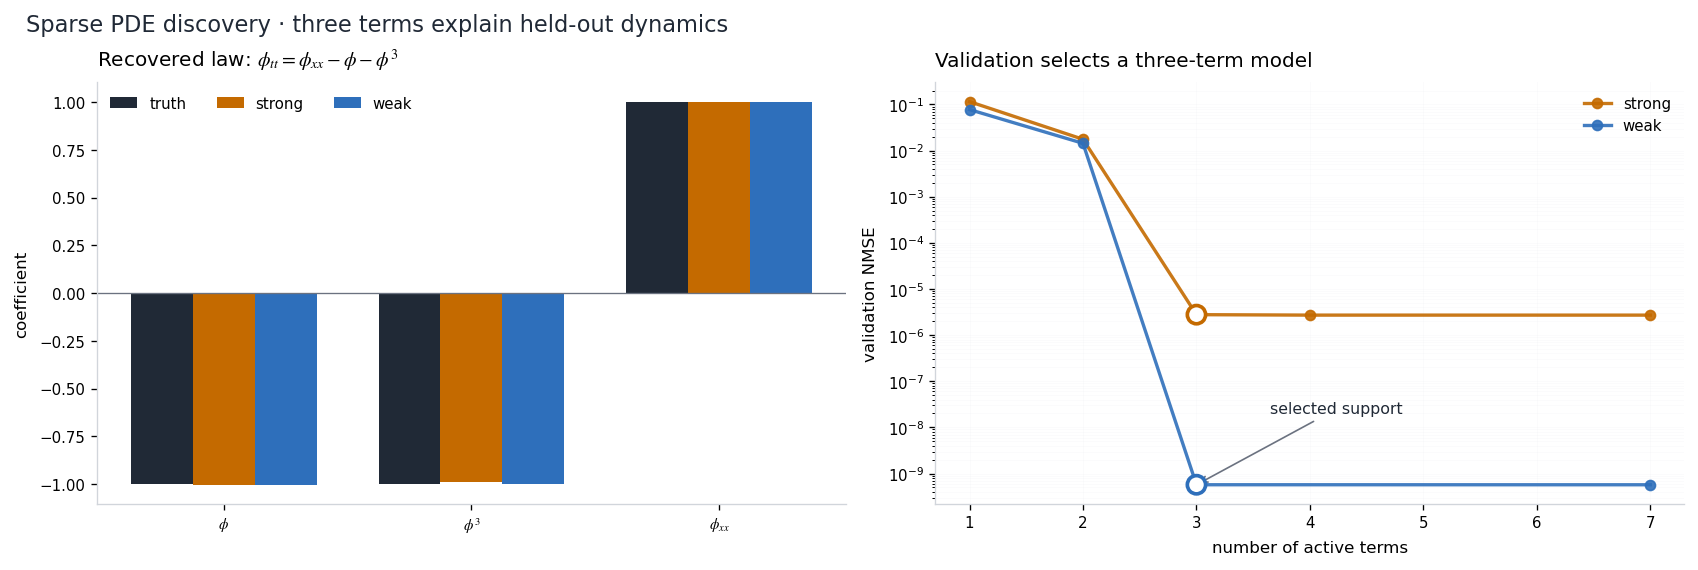

In [32]:
def compact_bump(half_width, spacing, power=4):
    coords = np.arange(-half_width, half_width + 1) * spacing
    radius = half_width * spacing
    z = coords / radius
    base = np.clip(1 - z**2, 0.0, None)
    bump = base**power
    bump_d1 = -2*power*z*base**(power-1) / radius
    bump_d2 = (-2*power*base**(power-1)
               + 4*power*(power-1)*z**2*base**(power-2)) / radius**2
    return bump, bump_d1, bump_d2

def weak_library(phi_observed, windows_per_trajectory=260, seed=0,
                 half_t=10, half_x=12):
    # Build the integrated weak library without differentiating observations.
    local_rng = np.random.default_rng(seed)
    bt, bt1, bt2 = compact_bump(half_t, DT_OBS)
    bx, bx1, bx2 = compact_bump(half_x, DX)
    psi = np.outer(bt, bx)
    psi_tt = np.outer(bt2, bx)
    psi_x = np.outer(bt, bx1)
    psi_xx = np.outer(bt, bx2)
    volume = DT_OBS * DX

    rows, targets = [], []
    n_time, n_space = phi_observed.shape[1:]
    offsets_x = np.arange(-half_x, half_x + 1)
    for trajectory in phi_observed:
        centers_t = local_rng.integers(half_t, n_time-half_t, size=windows_per_trajectory)
        centers_x = local_rng.integers(0, n_space, size=windows_per_trajectory)
        for ct, cx in zip(centers_t, centers_x):
            tidx = slice(ct-half_t, ct+half_t+1)
            xidx = (cx + offsets_x) % n_space
            patch = trajectory[tidx][:, xidx]
            rows.append([
                np.sum(psi),
                np.sum(patch * psi),
                np.sum(patch**2 * psi),
                np.sum(patch**3 * psi),
                np.sum(patch**5 * psi),
                -np.sum(patch * psi_x),
                np.sum(patch * psi_xx),
            ])
            targets.append(np.sum(patch * psi_tt))
    return volume*np.asarray(rows), volume*np.asarray(targets)

A_fit_w, b_fit_w = weak_library(phi_train[:5], seed=SEED)
A_val_w, b_val_w = weak_library(phi_train[5:6], seed=SEED+1)
weak_best, weak_path = fit_sparse_path(A_fit_w, b_fit_w, A_val_w, b_val_w)
weak_threshold, weak_clean_coef, weak_val_nmse, _ = weak_best

print("Ground truth: ", format_equation(TRUE_PDE_COEF))
print("Weak form:    ", format_equation(weak_clean_coef))
print(f"Selected threshold={weak_threshold:.3g}; validation NMSE={weak_val_nmse:.3e}")

comparison = pd.DataFrame({
    "term": PDE_TERMS,
    "ground truth": TRUE_PDE_COEF,
    "strong form": strong_clean_coef,
    "weak form": weak_clean_coef,
})
display(comparison.style.format({c: "{:+.4f}" for c in comparison.columns[1:]}))

pde_active = np.flatnonzero(np.abs(TRUE_PDE_COEF) > 1e-12)
xpos = np.arange(len(pde_active))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
fig.suptitle("Sparse PDE discovery · three terms explain held-out dynamics",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
axes[0].bar(xpos-width, TRUE_PDE_COEF[pde_active], width, label="truth", color=COLORS["ink"])
axes[0].bar(xpos, strong_clean_coef[pde_active], width, label="strong", color=COLORS["orange"])
axes[0].bar(xpos+width, weak_clean_coef[pde_active], width, label="weak", color=COLORS["blue"])
axes[0].axhline(0, color=COLORS["gray"], lw=0.8)
axes[0].set_xticks(xpos, np.asarray(PDE_LABELS)[pde_active])
axes[0].set(title=r"Recovered law: $\phi_{tt}=\phi_{xx}-\phi-\phi^3$",
            ylabel="coefficient")
axes[0].legend(ncol=3)

for frame, label, color in [(strong_path, "strong", COLORS["orange"]),
                            (weak_path, "weak", COLORS["blue"])]:
    pareto = (frame.groupby("support_size", as_index=False)["validation_NMSE"]
              .min().sort_values("support_size"))
    axes[1].plot(pareto["support_size"], pareto["validation_NMSE"], "o-",
                 ms=6, lw=2, alpha=0.9, label=label, color=color)
axes[1].scatter([3, 3], [strong_val_nmse, weak_val_nmse], s=120, marker="o",
                facecolor="white", edgecolor=[COLORS["orange"], COLORS["blue"]],
                linewidth=2.2, zorder=5)
axes[1].set_yscale("log")
axes[1].set(title="Validation selects a three-term model",
            xlabel="number of active terms",
            ylabel="validation NMSE")
axes[1].grid(alpha=0.16, which="both")
axes[1].annotate("selected support", xy=(3, weak_val_nmse), xytext=(3.65, 2e-8),
                 color=COLORS["ink"], fontsize=9.5,
                 arrowprops=dict(arrowstyle="->", color=COLORS["gray"], lw=1.0))
axes[1].legend(loc="upper right")
for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("02_clean_pde_discovery.png")
plt.show()

## 6. Controlled noise study

Gaussian measurement noise is reported relative to the global standard deviation of the clean training field. We repeat each noise level with **eight independent noise realizations**. Every realization is fitted on five trajectories and model-selected on the sixth. Error bars below are **95% Student-$t$ confidence intervals** across those repetitions.

The metrics are:

- **support F1:** whether the correct active terms were selected;
- **relative coefficient error:** $\|\hat\xi-\xi^\star\|_2/\|\xi^\star\|_2$;
- **validation NMSE:** derivative/integral residual normalized by target variance.

In [36]:
NOISE_LEVELS = np.array([0.00, 0.01, 0.02, 0.05, 0.10])
N_REPEATS = 8
field_scale = np.std(phi_train)

def noisy_copy(clean, noise_level, seed):
    local_rng = np.random.default_rng(seed)
    return clean + noise_level * field_scale * local_rng.standard_normal(clean.shape)

records = []
saved_weak_models = {}
start = time.perf_counter()
for noise in NOISE_LEVELS:
    for repeat in range(N_REPEATS):
        observed = noisy_copy(phi_train, noise, SEED + 1000 + 37*repeat + int(1000*noise))

        Asf, bsf = strong_library(observed[:5], seed=SEED+repeat)
        Asv, bsv = strong_library(observed[5:6], max_rows=35_000, seed=SEED+50+repeat)
        best_s, _ = fit_sparse_path(Asf, bsf, Asv, bsv)

        Awf, bwf = weak_library(observed[:5], seed=SEED+100+repeat)
        Awv, bwv = weak_library(observed[5:6], seed=SEED+200+repeat)
        best_w, _ = fit_sparse_path(Awf, bwf, Awv, bwv)

        for method, best in [("Strong", best_s), ("Weak", best_w)]:
            threshold, coef, nmse, support = best
            records.append({
                "noise": noise,
                "repeat": repeat,
                "method": method,
                "threshold": threshold,
                "support_size": support,
                "support_F1": support_f1(coef),
                "coefficient_error": coefficient_error(coef),
                "validation_NMSE": nmse,
                "coefficients": coef,
            })
        if repeat == 0:
            saved_weak_models[float(noise)] = best_w[1]

noise_results = pd.DataFrame(records)
elapsed = time.perf_counter() - start
print(f"Completed {len(records)} fitted models in {elapsed:.1f} s")

summary = (noise_results.groupby(["method", "noise"])
           .agg(F1_mean=("support_F1", "mean"),
                F1_std=("support_F1", "std"),
                coef_error_mean=("coefficient_error", "mean"),
                coef_error_std=("coefficient_error", "std"),
                NMSE_mean=("validation_NMSE", "mean"),
                NMSE_std=("validation_NMSE", "std"),
                n=("coefficient_error", "size"))
           .reset_index())
summary["coef_error_CI95"] = ci95_from_std(summary.coef_error_std, summary.n)
summary["NMSE_CI95"] = ci95_from_std(summary.NMSE_std, summary.n)
display(summary.style.format({
    "noise": "{:.0%}", "F1_mean": "{:.3f}", "F1_std": "{:.3f}",
    "coef_error_mean": "{:.3f}", "coef_error_std": "{:.3f}",
    "coef_error_CI95": "{:.3f}", "NMSE_mean": "{:.3e}",
    "NMSE_std": "{:.3e}", "NMSE_CI95": "{:.3e}",
}))

Completed 80 fitted models in 9.4 s


,method,noise,F1_mean,F1_std,coef_error_mean,coef_error_std,NMSE_mean,NMSE_std,n,coef_error_CI95,NMSE_CI95
0,Strong,0%,1.000,0.000,0.006,0.000,2.719e-06,3.170e-08,8,0.000,2.651e-08
1,Strong,1%,1.000,0.000,0.006,0.001,2.452e-03,6.842e-05,8,0.001,5.720e-05
2,Strong,2%,1.000,0.000,0.006,0.001,9.646e-03,3.404e-04,8,0.001,2.846e-04
3,Strong,5%,1.000,0.000,0.021,0.002,5.610e-02,1.240e-03,8,0.001,1.037e-03
4,Strong,10%,1.000,0.000,0.067,0.006,1.799e-01,3.882e-03,8,0.005,3.246e-03
5,Weak,0%,1.000,0.000,0.002,0.000,7.094e-10,1.061e-10,8,0.000,8.868e-11
6,Weak,1%,1.000,0.000,0.002,0.000,2.060e-04,2.523e-05,8,0.000,2.109e-05
7,Weak,2%,1.000,0.000,0.004,0.002,7.937e-04,5.297e-05,8,0.001,4.428e-05
8,Weak,5%,1.000,0.000,0.004,0.003,5.100e-03,9.268e-04,8,0.002,7.748e-04
9,Weak,10%,1.000,0.000,0.013,0.007,1.920e-02,2.525e-03,8,0.006,2.111e-03


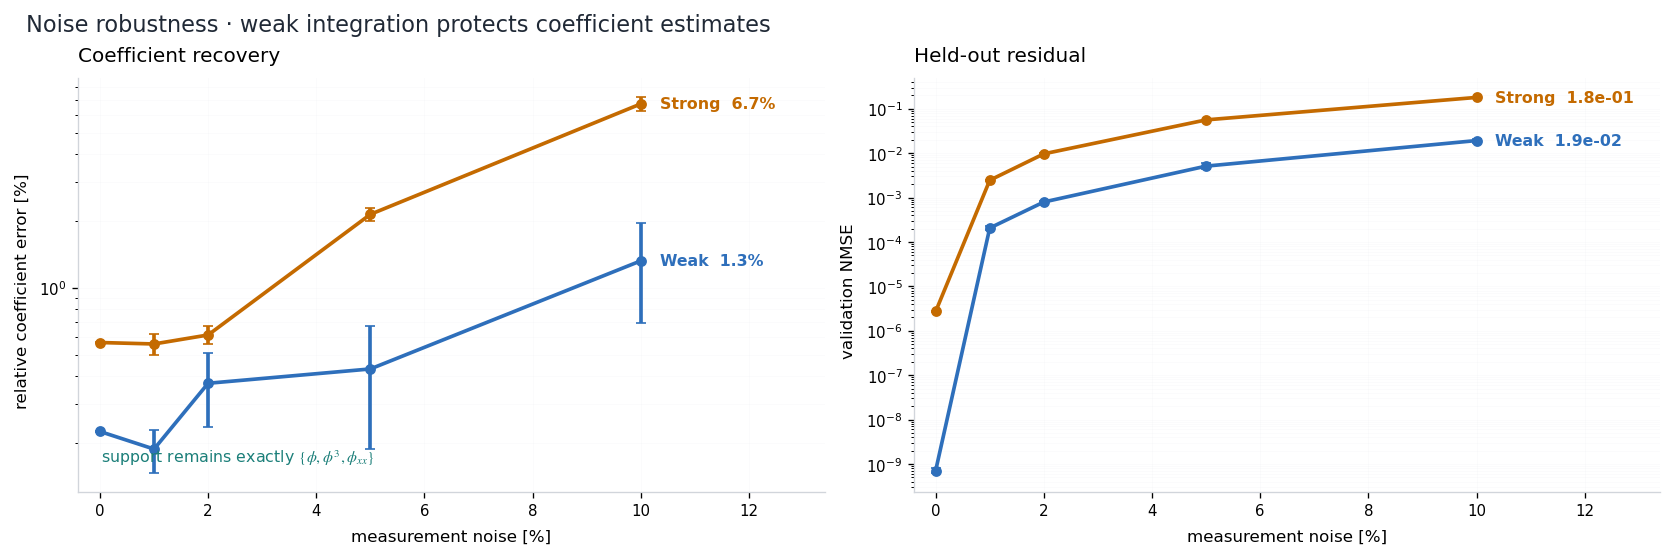

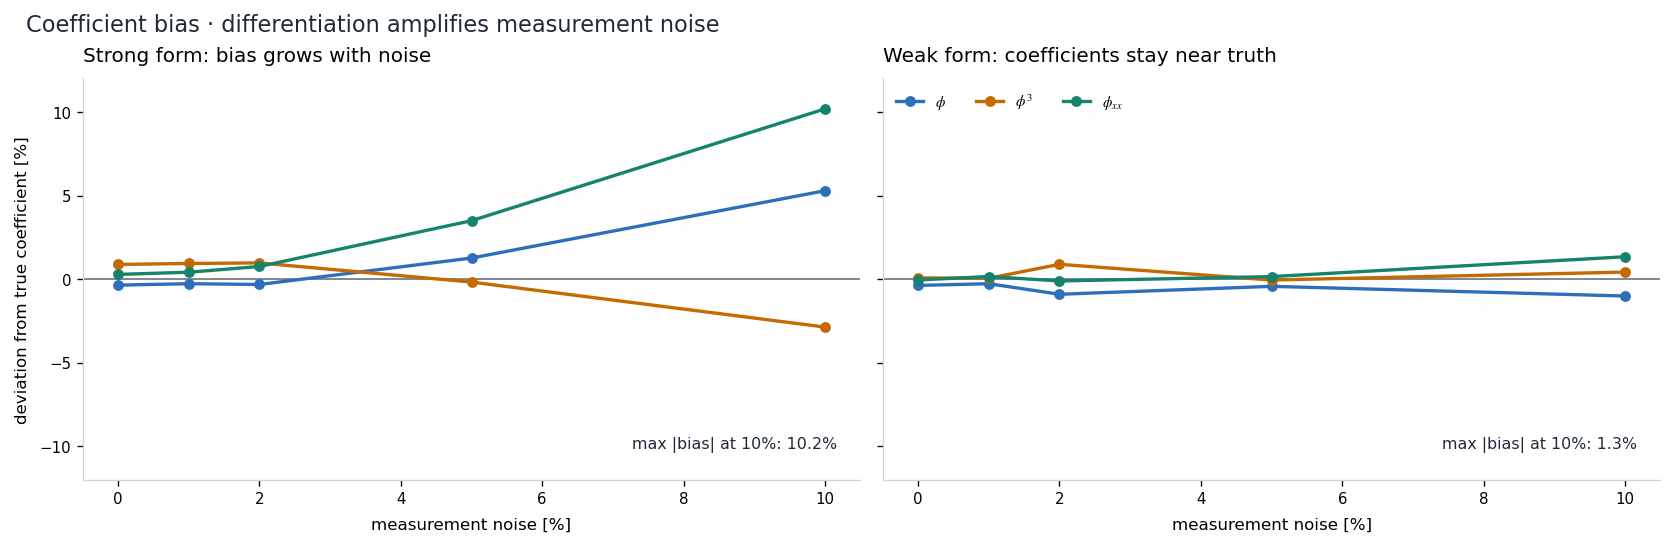

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.5), constrained_layout=True)
fig.suptitle("Noise robustness · weak integration protects coefficient estimates",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
metric_specs = [
    ("coefficient_error", "Coefficient recovery"),
    ("validation_NMSE", "Held-out residual"),
]
method_colors = {"Strong": COLORS["orange"], "Weak": COLORS["blue"]}
for ax, (metric, title) in zip(axes, metric_specs):
    for method in ["Strong", "Weak"]:
        subset = noise_results[noise_results.method == method]
        means = subset.groupby("noise")[metric].mean().reindex(NOISE_LEVELS)
        stds = subset.groupby("noise")[metric].std().reindex(NOISE_LEVELS).fillna(0)
        ci95 = ci95_from_std(stds, N_REPEATS)
        scale = 100.0 if metric == "coefficient_error" else 1.0
        plot_means = scale*means
        plot_ci95 = scale*ci95
        ax.errorbar(100*NOISE_LEVELS, plot_means, yerr=plot_ci95, marker="o", capsize=3,
                    lw=2.2, label=method, color=method_colors[method])
        endpoint = (f"{method}  {100*means.iloc[-1]:.1f}%"
                    if metric == "coefficient_error"
                    else f"{method}  {means.iloc[-1]:.1e}")
        ax.text(10.35, plot_means.iloc[-1], endpoint,
                color=method_colors[method], va="center", fontsize=9.5,
                fontweight="bold")
    ax.set_yscale("log")
    ax.set(title=title, xlabel="measurement noise [%]", xlim=(-0.4, 13.4))
    ax.grid(alpha=0.16, which="both")
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
axes[0].set_ylabel("relative coefficient error [%]  ")
axes[1].set_ylabel("validation NMSE  ")
axes[0].text(
    0.03, 0.06, r"support remains exactly $\{\phi,\phi^3,\phi_{xx}\}$",
    transform=axes[0].transAxes, ha="left", va="bottom",
    fontsize=9.5, color=COLORS["teal"],
)
savefig("03_noise_robustness_pde.png")
plt.show()

# Bias of the three active coefficients for one representative realization.
active_idx = np.flatnonzero(TRUE_PDE_COEF)
active_labels = [r"$\phi$", r"$\phi^3$", r"$\phi_{xx}$"]
active_colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
path_bias = {}
for method in ["Strong", "Weak"]:
    representative = noise_results[(noise_results.method == method) & (noise_results.repeat == 0)]
    coef_matrix = np.vstack(representative.sort_values("noise").coefficients)
    path_bias[method] = 100 * ((coef_matrix[:, active_idx] - TRUE_PDE_COEF[active_idx])
                               / np.abs(TRUE_PDE_COEF[active_idx]))

max_bias = max(3.0, max(np.max(np.abs(v)) for v in path_bias.values()))
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.4), sharey=True, constrained_layout=True)
fig.suptitle("Coefficient bias · differentiation amplifies measurement noise",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
panel_titles = ["Strong form: bias grows with noise", "Weak form: coefficients stay near truth"]
for ax, method, title in zip(axes, ["Strong", "Weak"], panel_titles):
    bias = path_bias[method]
    ax.axhline(0, color=COLORS["gray"], lw=1.0)
    for k, (label, color) in enumerate(zip(active_labels, active_colors)):
        ax.plot(100*NOISE_LEVELS, bias[:, k], marker="o", lw=2,
                color=color, label=label)
    ax.set(title=title, xlabel="measurement noise [%]",
           ylim=(-1.18*max_bias, 1.18*max_bias))
    ax.grid(alpha=0.15)
    ax.text(0.97, 0.08, f"max |bias| at 10%: {np.max(np.abs(bias[-1])):.1f}%",
            transform=ax.transAxes, ha="right", color=COLORS["ink"], fontsize=9.5)
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
axes[0].set_ylabel("deviation from true coefficient [%]")
axes[1].legend(ncol=3, loc="upper left", fontsize=9)
savefig("04_coefficient_paths.png")
plt.show()

## 7. Physical validation: rollout on an unseen initial condition

A low residual is not sufficient: the learned equation should reproduce dynamics from an initial condition never used in fitting or model selection. We therefore integrate the equation discovered from the **2% noisy** training data and compare it with the held-out ground truth.

Equation used for rollout:
phi_tt = -1.0091 phi -0.9911 phi^3 +0.9989 phi_xx
Median relative field error: 9.563e-03
Final relative field error:  1.580e-02


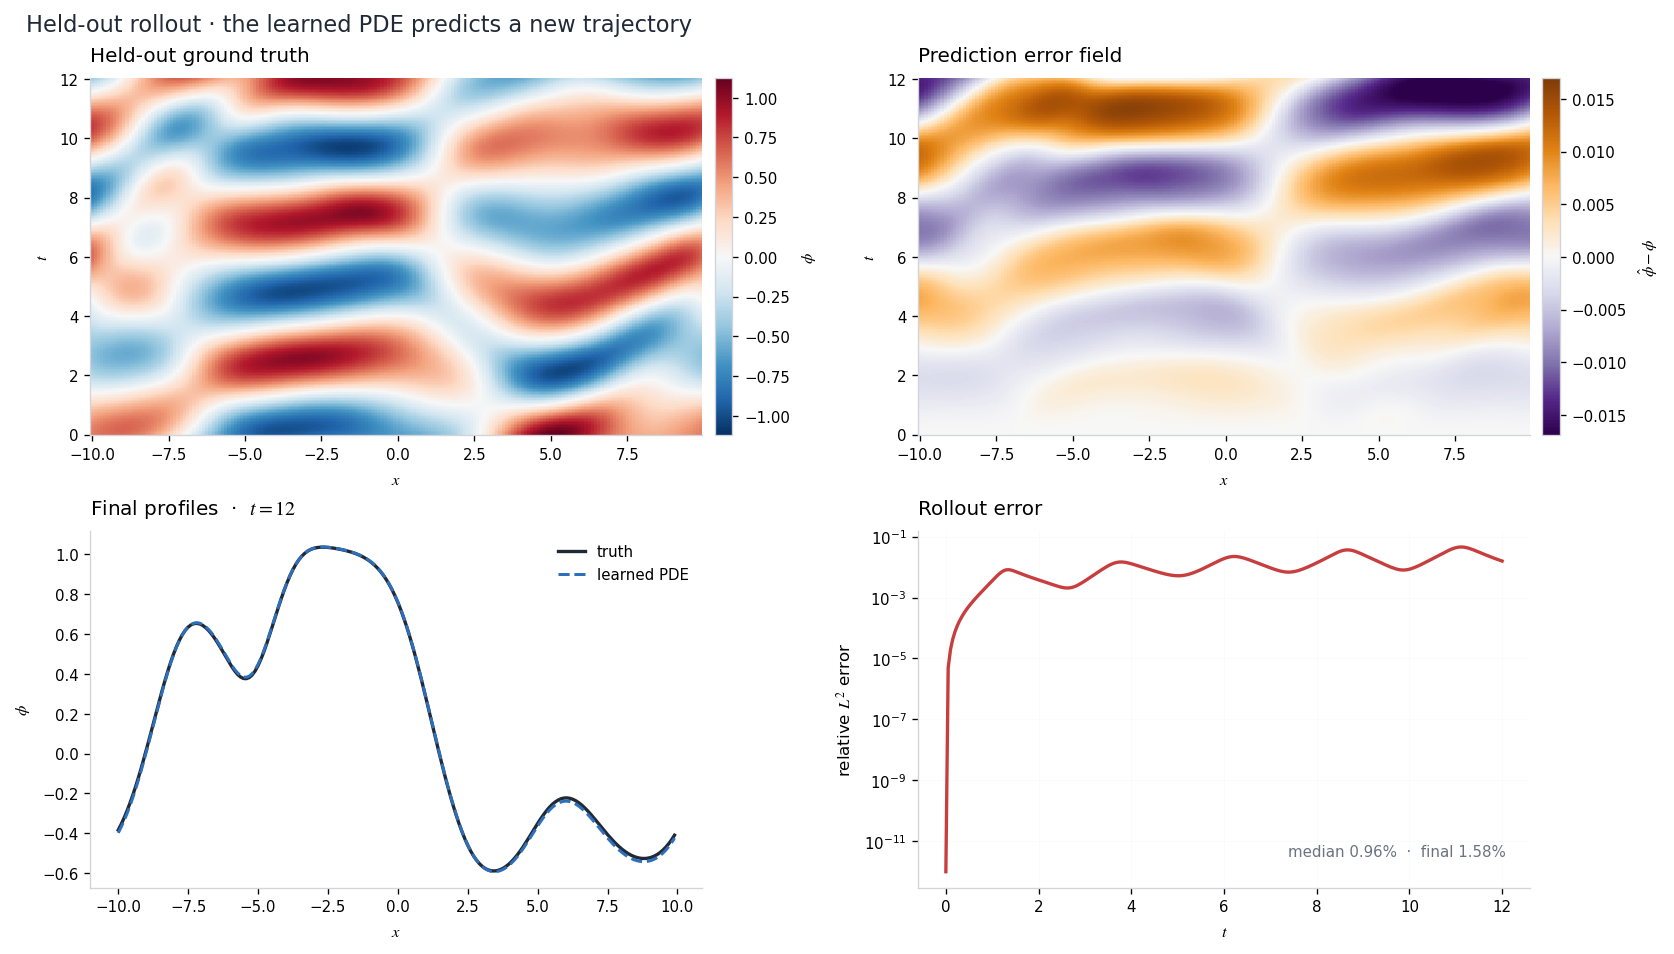

In [39]:
rollout_noise = 0.02
rollout_coef = saved_weak_models[rollout_noise]
learned_acceleration = lambda phi: library_acceleration(phi, rollout_coef)
phi_learned, pi_learned = simulate(phi_test[0, 0], pi_test[0, 0], learned_acceleration)
phi_reference = phi_test[0]
rollout_error = (np.linalg.norm(phi_learned - phi_reference, axis=1)
                 / np.maximum(np.linalg.norm(phi_reference, axis=1), 1e-12))

print("Equation used for rollout:")
print(format_equation(rollout_coef))
print(f"Median relative field error: {np.median(rollout_error):.3e}")
print(f"Final relative field error:  {rollout_error[-1]:.3e}")

fig, axes = plt.subplots(2, 2, figsize=(13.8, 7.8), constrained_layout=True)
fig.suptitle("Held-out rollout · the learned PDE predicts a new trajectory",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
lim = np.max(np.abs(phi_reference))
im0 = axes[0,0].pcolormesh(x, t_obs, phi_reference, shading="auto",
                            cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[0,0].set(title="Held-out ground truth", xlabel="$x$", ylabel="$t$")
fig.colorbar(im0, ax=axes[0,0], label="$\phi$", fraction=0.046, pad=0.02)

field_difference = phi_learned - phi_reference
diff_lim = max(np.percentile(np.abs(field_difference), 99), 1e-6)
im1 = axes[0,1].pcolormesh(x, t_obs, field_difference, shading="auto",
                            cmap="PuOr_r", vmin=-diff_lim, vmax=diff_lim)
axes[0,1].set(title="Prediction error field", xlabel="$x$", ylabel="$t$")
fig.colorbar(im1, ax=axes[0,1], label=r"$\hat\phi-\phi$", fraction=0.046, pad=0.02)

axes[1,0].plot(x, phi_reference[-1], color=COLORS["ink"], lw=2, label="truth")
axes[1,0].plot(x, phi_learned[-1], color=COLORS["blue"], lw=1.8, ls="--", label="learned PDE")
axes[1,0].set(title=f"Final profiles  ·  $t={t_obs[-1]:.0f}$",
              xlabel="$x$", ylabel="$\phi$")
axes[1,0].legend()

axes[1,1].semilogy(t_obs, np.maximum(rollout_error, 1e-12), color=COLORS["red"], lw=2)
axes[1,1].set(title="Rollout error", xlabel="$t$",
              ylabel="relative $L^2$ error")
axes[1,1].grid(alpha=0.18)
axes[1,1].text(0.96, 0.08,
               f"median {100*np.median(rollout_error):.2f}%  ·  final {100*rollout_error[-1]:.2f}%",
               transform=axes[1,1].transAxes, ha="right", va="bottom",
               color=COLORS["gray"], fontsize=9.0)
for ax in axes.ravel():
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("05_heldout_rollout.png")
plt.show()

## 8. Discovering Noether charges from data

Define global candidate quantities

$$Q_j(t)=\int q_j(\phi,\phi_t,\phi_x)\,dx.$$

A conserved charge is a coefficient vector $a$ such that $Q(t)a$ is constant. For every trajectory we subtract its own temporal mean and stack the centered matrices. Conserved quantities then lie in the approximate null space.

Write the centered and column-scaled library as

$$\widetilde Q=U\Sigma V^T.$$

The right singular vector $v_k$ satisfies

$$\|\widetilde Qv_k\|_2=\sigma_k.$$

Therefore the right singular vectors associated with the smallest singular values minimize temporal variation and are the data-driven candidates for conserved charges. A large gap between the second and third smallest singular values supports a two-dimensional conserved subspace. SVD identifies this subspace, but not unique physical names: any rotation of energy and momentum spans the same null space.

Because energy and momentum span a two-dimensional null space, singular vectors alone are arbitrary rotations of the physical charges. We resolve this ambiguity with a sparse two-stage procedure:

1. score each individual candidate by its centered temporal variation and extract the best one-term invariant;
2. remove that direction and use the smallest singular vector of the remaining library to recover the independent multi-term invariant.

This is appropriate here because momentum is represented by the single candidate $\int\phi_t\phi_x\,dx$, whereas energy is a sparse combination of four candidates.

In [10]:
CHARGE_TERMS = [
    "int pi^2", "int phi_x^2", "int phi^2", "int phi^4",
    "int phi^6", "int pi*phi_x", "int phi*pi", "int phi_x^4"
]
TRUE_ENERGY_COEF = np.array([1.0, C**2, MASS**2, LAMBDA/2, 0.0, 0.0, 0.0, 0.0])
TRUE_MOMENTUM_COEF = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0])

def charge_library_from_observations(phi_observed):
    # Estimate phi_t and phi_x from field-only observations, then integrate candidates.
    wt, wx = 15, 13
    smooth_t = savgol_filter(phi_observed, wt, 5, axis=1, mode="interp")
    smooth = savgol_filter(smooth_t, wx, 5, axis=2, mode="wrap")
    pi_est = savgol_filter(smooth, wt, 5, deriv=1, delta=DT_OBS, axis=1, mode="interp")
    phi_x_est = savgol_filter(smooth, wx, 5, deriv=1, delta=DX, axis=2, mode="wrap")
    densities = [
        pi_est**2,
        phi_x_est**2,
        smooth**2,
        smooth**4,
        smooth**6,
        pi_est * phi_x_est,
        smooth * pi_est,
        phi_x_est**4,
    ]
    Q = np.stack([DX*np.sum(d, axis=-1) for d in densities], axis=-1)
    return Q, smooth, pi_est, phi_x_est

def discover_two_charges(Q, rotation_points=None):
    centered = np.concatenate([traj - traj.mean(axis=0, keepdims=True) for traj in Q], axis=0)
    scale = np.sqrt(np.mean(Q.reshape(-1, Q.shape[-1])**2, axis=0))
    scale[scale < 1e-12] = 1.0
    _, singular_values, _ = np.linalg.svd(centered / scale, full_matrices=False)

    # Stage 1: exact sparsity search over one-term candidate invariants.
    relative_variation = np.linalg.norm(centered, axis=0) / (
        np.linalg.norm(Q.reshape(-1, Q.shape[-1]), axis=0) + 1e-14
    )
    momentum_index = int(np.argmin(relative_variation))
    momentum = np.zeros(Q.shape[-1])
    momentum[momentum_index] = 1.0

    # Stage 2: remove the one-term invariant and recover the remaining
    # multi-term invariant from the smallest singular direction.
    keep = np.array([j for j in range(Q.shape[-1]) if j != momentum_index])
    _, _, Vt_reduced = np.linalg.svd(centered[:, keep] / scale[keep], full_matrices=False)
    energy = np.zeros(Q.shape[-1])
    energy[keep] = Vt_reduced[-1] / scale[keep]
    if energy[0] < 0:
        energy *= -1
    energy /= energy[0]
    energy[np.abs(energy) < 0.02] = 0.0
    return energy, momentum, singular_values

def charge_drift(Q, coef):
    charge = Q @ coef
    drifts = []
    for values in charge:
        scale = max(np.mean(np.abs(values)), 1e-12)
        drifts.append((values.max() - values.min()) / scale)
    return float(np.mean(drifts))

Q_clean, _, _, _ = charge_library_from_observations(phi_train)
energy_coef_clean, momentum_coef_clean, singular_values = discover_two_charges(Q_clean)
Q_test_clean, _, _, _ = charge_library_from_observations(phi_test)

charge_table = pd.DataFrame({
    "candidate integral": CHARGE_TERMS,
    "true energy": TRUE_ENERGY_COEF,
    "discovered energy": energy_coef_clean,
    "true momentum": TRUE_MOMENTUM_COEF,
    "discovered momentum": momentum_coef_clean,
})
display(charge_table.style.format({c: "{:+.4f}" for c in charge_table.columns[1:]}))

print(f"Held-out energy drift:   {charge_drift(Q_test_clean, energy_coef_clean):.3e}")
print(f"Held-out momentum drift: {charge_drift(Q_test_clean, momentum_coef_clean):.3e}")

,candidate integral,true energy,discovered energy,true momentum,discovered momentum
0,int pi^2,+1.0000,+1.0000,+0.0000,+0.0000
1,int phi_x^2,+1.0000,+1.0006,+0.0000,+0.0000
2,int phi^2,+1.0000,+0.9998,+0.0000,+0.0000
3,int phi^4,+0.5000,+0.5005,+0.0000,+0.0000
4,int phi^6,+0.0000,+0.0000,+0.0000,+0.0000
5,int pi*phi_x,+0.0000,+0.0000,+1.0000,+1.0000
6,int phi*pi,+0.0000,+0.0000,+0.0000,+0.0000
7,int phi_x^4,+0.0000,+0.0000,+0.0000,+0.0000


Held-out energy drift:   7.684e-04
Held-out momentum drift: 1.280e-03


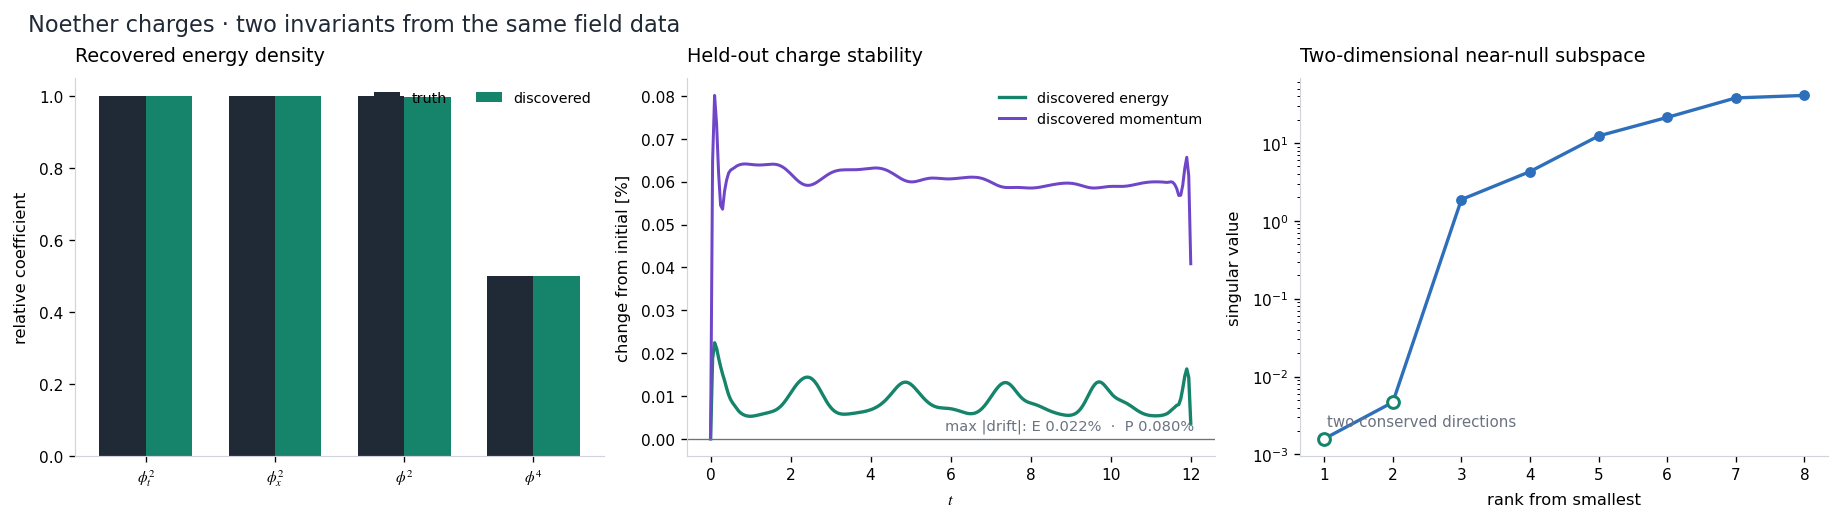

In [11]:
discovered_energy = Q_test_clean[0] @ energy_coef_clean
discovered_momentum = Q_test_clean[0] @ momentum_coef_clean

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.2), constrained_layout=True)
fig.suptitle("Noether charges · two invariants from the same field data",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
charge_active = np.flatnonzero(np.abs(TRUE_ENERGY_COEF) > 1e-12)
charge_labels = np.array([r"$\phi_t^2$", r"$\phi_x^2$", r"$\phi^2$", r"$\phi^4$",
                          r"$\phi^6$", r"$\phi_t\phi_x$", r"$\phi\phi_t$", r"$\phi_x^4$"])
charge_x = np.arange(len(charge_active))
axes[0].bar(charge_x-0.18, TRUE_ENERGY_COEF[charge_active], 0.36,
            color=COLORS["ink"], label="truth")
axes[0].bar(charge_x+0.18, energy_coef_clean[charge_active], 0.36,
            color=COLORS["green"], label="discovered")
axes[0].set_xticks(charge_x, charge_labels[charge_active])
axes[0].set(title="Recovered energy density",
            ylabel="relative coefficient")
axes[0].legend(ncol=2, loc="upper right")

energy_drift_pct = 100*(discovered_energy/discovered_energy[0]-1)
momentum_drift_pct = 100*(discovered_momentum/discovered_momentum[0]-1)
axes[1].plot(t_obs, energy_drift_pct,
             color=COLORS["green"], lw=2, label="discovered energy")
axes[1].plot(t_obs, momentum_drift_pct,
             color=COLORS["purple"], lw=1.8, label="discovered momentum")
axes[1].axhline(0, color=COLORS["gray"], lw=0.8)
axes[1].set(title="Held-out charge stability",
            xlabel="$t$", ylabel="change from initial [%]")
axes[1].text(0.96, 0.06,
             f"max |drift|: E {np.max(np.abs(energy_drift_pct)):.3f}%  ·  "
             f"P {np.max(np.abs(momentum_drift_pct)):.3f}%",
             transform=axes[1].transAxes, ha="right", va="bottom",
             fontsize=8.8, color=COLORS["gray"])
axes[1].legend(loc="upper right")

axes[2].semilogy(np.arange(1, len(singular_values)+1), singular_values[::-1], "o-",
                 color=COLORS["blue"], lw=2)
axes[2].scatter([1, 2], singular_values[::-1][:2], s=50,
                facecolor="white", edgecolor=COLORS["green"], linewidth=1.8, zorder=3)
axes[2].set(title="Two-dimensional near-null subspace", xlabel="rank from smallest",
            ylabel="singular value")
axes[2].text(0.05, 0.08, "two conserved directions",
             transform=axes[2].transAxes, fontsize=9.0, color=COLORS["gray"])
for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("06_noether_charge_discovery.png")
plt.show()

### 8.1 Scientific consistency audit: two independent routes must agree

The mathematical reference is the Lagrangian density

$$
\mathcal L=\frac12\phi_t^2-\frac{c^2}{2}\phi_x^2
-\frac{m^2}{2}\phi^2-\frac{\lambda}{4}\phi^4.
$$

Its Euler–Lagrange equation is

$$
\phi_{tt}=c^2\phi_{xx}-m^2\phi-\lambda\phi^3,
$$

while time-translation symmetry gives the Noether energy density

$$
\rho_E=\frac12\phi_t^2+\frac{c^2}{2}\phi_x^2
+\frac{m^2}{2}\phi^2+\frac{\lambda}{4}\phi^4.
$$

Therefore, if sparse regression learns

$$\phi_{tt}=a\phi_{xx}+b\phi+d\phi^3,$$

it independently predicts the normalized energy coefficients

$$[\phi_t^2,\phi_x^2,\phi^2,\phi^4]=[1,a,-b,-d/2].$$

This prediction does **not** use the conservation-law null-space fit. Agreement between the PDE-implied density and the independently discovered conserved density is therefore a nontrivial cross-check. The test below also evaluates the learned operator on an entire trajectory excluded from fitting. These are strong numerical consistency tests, not a formal theorem proving uniqueness from arbitrary finite data.

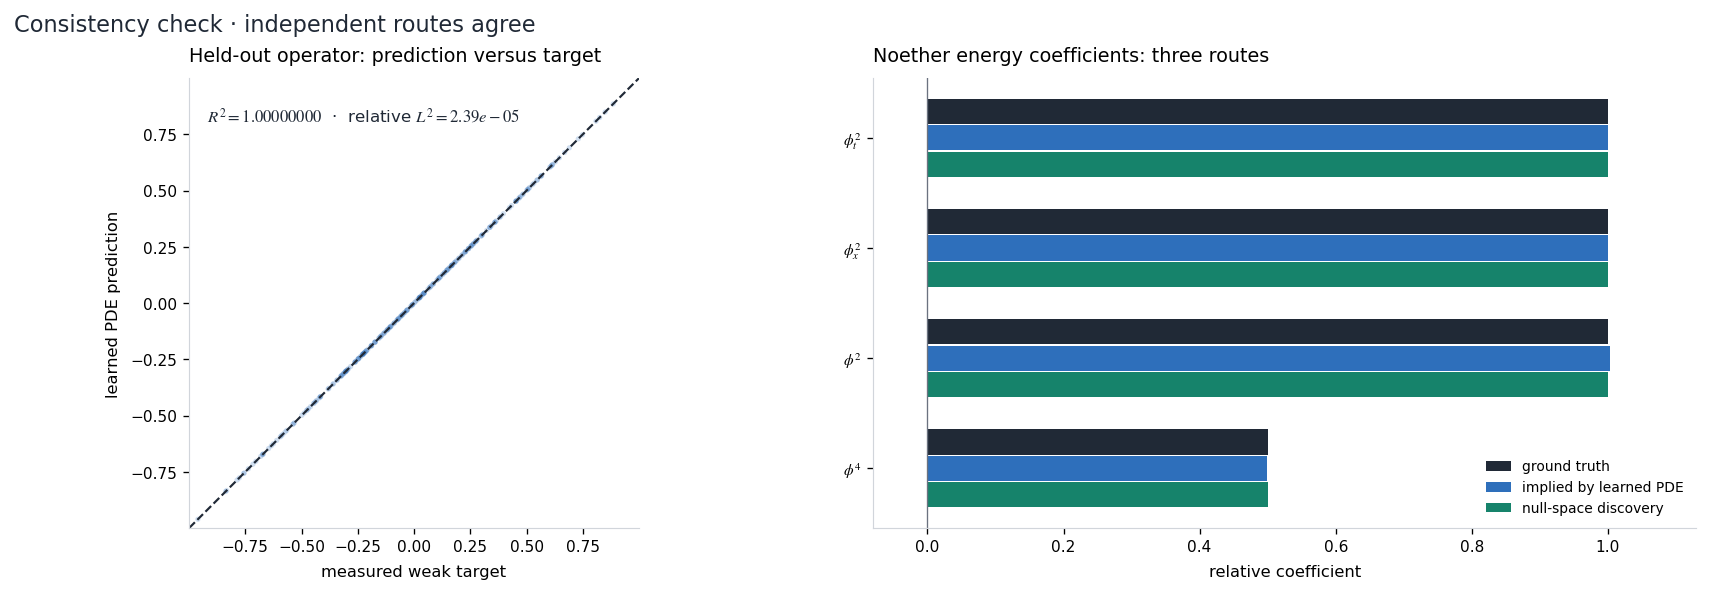

,test,observed result,scientific meaning
0,held-out weak-operator agreement,R²=1.00000000; relative L²=2.39e-05; slope=0.999998,the learned differential operator generalizes to an excluded trajectory
1,weak-form support recovery over all noisy trials,40/40 exact supports,the correct three-term PDE structure is stable across noise realizations
2,weak-form coefficient error at 10% noise,"mean=1.321% ± 0.626% (95% CI, n=8)",coefficient estimates remain accurate despite derivative noise
3,unseen nonlinear rollout,median field error=0.956%; final=1.580%,"small residuals translate into predictive dynamics, not only regression fit"
4,PDE-implied versus independently discovered energy,cosine=0.9999975; relative difference=0.236%,equation discovery and conservation discovery give the same physics
5,null-space separation,third/s₂ singular-value gap=402.3×,two conserved directions are spectrally separated from non-invariants
6,clean held-out charge conservation,energy drift=0.077%; momentum drift=0.128%,both recovered charges remain nearly constant on unseen dynamics


In [12]:
# Held-out weak-operator residual: no points from this trajectory entered fitting.
weak_target_holdout = b_val_w
weak_prediction_holdout = A_val_w @ weak_clean_coef
weak_residual_holdout = weak_target_holdout - weak_prediction_holdout
weak_operator_r2 = 1 - (np.sum(weak_residual_holdout**2)
                        / np.sum((weak_target_holdout - weak_target_holdout.mean())**2))
weak_operator_rel_l2 = (np.linalg.norm(weak_residual_holdout)
                        / np.linalg.norm(weak_target_holdout))
weak_operator_slope = (np.dot(weak_target_holdout, weak_prediction_holdout)
                       / np.dot(weak_target_holdout, weak_target_holdout))

# Energy coefficients implied by the independently learned PDE.
pde_implied_energy = np.zeros_like(TRUE_ENERGY_COEF)
pde_implied_energy[0] = 1.0
pde_implied_energy[1] = weak_clean_coef[6]
pde_implied_energy[2] = -weak_clean_coef[1]
pde_implied_energy[3] = -0.5 * weak_clean_coef[3]
pde_implied_energy /= pde_implied_energy[0]

energy_route_cosine = (np.dot(pde_implied_energy, energy_coef_clean)
                       / (np.linalg.norm(pde_implied_energy)
                          * np.linalg.norm(energy_coef_clean)))
energy_route_rel_difference = (np.linalg.norm(pde_implied_energy-energy_coef_clean)
                               / np.linalg.norm(pde_implied_energy))
nullspace_spectral_gap = singular_values[-3] / max(singular_values[-2], 1e-15)

weak_rows = noise_results[noise_results.method == "Weak"]
exact_support_count = int(np.sum(np.isclose(weak_rows.support_F1, 1.0)))
weak_10 = weak_rows[np.isclose(weak_rows.noise, 0.10)].coefficient_error
weak_10_ci95 = float(ci95_from_std(weak_10.std(), len(weak_10)))
clean_energy_drift = charge_drift(Q_test_clean, energy_coef_clean)
clean_momentum_drift = charge_drift(Q_test_clean, momentum_coef_clean)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8), constrained_layout=True)
fig.suptitle("Consistency check · independent routes agree",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])

plot_stride = max(1, len(weak_target_holdout)//3500)
axes[0].scatter(weak_target_holdout[::plot_stride],
                weak_prediction_holdout[::plot_stride],
                s=10, alpha=0.22, color=COLORS["blue"], edgecolors="none")
identity_lim = 1.04 * max(np.max(np.abs(weak_target_holdout)),
                          np.max(np.abs(weak_prediction_holdout)))
axes[0].plot([-identity_lim, identity_lim], [-identity_lim, identity_lim],
             color=COLORS["ink"], lw=1.3, ls="--", label="identity")
axes[0].set(title="Held-out operator: prediction versus target",
            xlabel="measured weak target", ylabel="learned PDE prediction",
            xlim=(-identity_lim, identity_lim), ylim=(-identity_lim, identity_lim))
axes[0].set_aspect("equal", adjustable="box")
axes[0].text(0.04, 0.94,
             rf"$R^2={weak_operator_r2:.8f}$  ·  relative $L^2={weak_operator_rel_l2:.2e}$",
             transform=axes[0].transAxes, va="top", fontsize=10,
             color=COLORS["ink"])

audit_active = np.flatnonzero(np.abs(TRUE_ENERGY_COEF) > 1e-12)
audit_labels_all = np.array([r"$\phi_t^2$", r"$\phi_x^2$", r"$\phi^2$", r"$\phi^4$",
                             r"$\phi^6$", r"$\phi_t\phi_x$", r"$\phi\phi_t$", r"$\phi_x^4$"])
audit_y = np.arange(len(audit_active))
axes[1].barh(audit_y-0.24, TRUE_ENERGY_COEF[audit_active], 0.23,
             color=COLORS["ink"], label="ground truth")
axes[1].barh(audit_y, pde_implied_energy[audit_active], 0.23,
             color=COLORS["blue"], label="implied by learned PDE")
axes[1].barh(audit_y+0.24, energy_coef_clean[audit_active], 0.23,
             color=COLORS["green"], label="null-space discovery")
axes[1].set_yticks(audit_y, audit_labels_all[audit_active])
axes[1].invert_yaxis()
axes[1].set(title="Noether energy coefficients: three routes",
            xlabel="relative coefficient", xlim=(-0.08, 1.13))
axes[1].axvline(0, color=COLORS["gray"], lw=0.8)
axes[1].legend(fontsize=8.3, loc="lower right")
for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("09_scientific_consistency.png")
plt.show()

scientific_evidence = pd.DataFrame({
    "test": [
        "held-out weak-operator agreement",
        "weak-form support recovery over all noisy trials",
        "weak-form coefficient error at 10% noise",
        "unseen nonlinear rollout",
        "PDE-implied versus independently discovered energy",
        "null-space separation",
        "clean held-out charge conservation",
    ],
    "observed result": [
        f"R²={weak_operator_r2:.8f}; relative L²={weak_operator_rel_l2:.2e}; slope={weak_operator_slope:.6f}",
        f"{exact_support_count}/{len(weak_rows)} exact supports",
        f"mean={weak_10.mean():.3%} ± {weak_10_ci95:.3%} (95% CI, n={len(weak_10)})",
        f"median field error={np.median(rollout_error):.3%}; final={rollout_error[-1]:.3%}",
        f"cosine={energy_route_cosine:.7f}; relative difference={energy_route_rel_difference:.3%}",
        f"third/s₂ singular-value gap={nullspace_spectral_gap:.1f}×",
        f"energy drift={clean_energy_drift:.3%}; momentum drift={clean_momentum_drift:.3%}",
    ],
    "scientific meaning": [
        "the learned differential operator generalizes to an excluded trajectory",
        "the correct three-term PDE structure is stable across noise realizations",
        "coefficient estimates remain accurate despite derivative noise",
        "small residuals translate into predictive dynamics, not only regression fit",
        "equation discovery and conservation discovery give the same physics",
        "two conserved directions are spectrally separated from non-invariants",
        "both recovered charges remain nearly constant on unseen dynamics",
    ],
})
display(scientific_evidence.style.set_properties(subset=["scientific meaning"],
                                                 **{"text-align": "left"}))

### 8.2 Local Noether laws: discovering density and flux simultaneously

Global conservation, $d\int\rho\,dx/dt=0$, is necessary but not sufficient to show that a quantity is transported locally. Periodic spatial integration can cancel positive and negative local errors. We therefore ask the stronger question

$$
\partial_t\rho(x,t)+\partial_xJ(x,t)=0.
$$

Both the density and flux are unknown sparse combinations,

$$
\rho=\Theta_\rho a,
\qquad
J=\Theta_J b.
$$

Multiplying by a compact test function and integrating by parts gives

$$
\iint \left(\rho\,\psi_t+J\,\psi_x\right)dxdt=0.
$$

This weak equation requires only first-derivative estimates inside the candidate fields; it never differentiates the noisy density or flux directly. SVD identifies a two-dimensional local-conservation subspace, and a sparse rotation separates the energy and momentum continuity laws.

,candidate,energy truth,energy discovered,momentum truth,momentum discovered
0,$\rho:$ $\phi_t^2$,+1.0000,+1.0000,+0.0000,+0.0000
1,$\rho:$ $\phi_x^2$,+1.0000,+1.0004,+0.0000,+0.0000
2,$\rho:$ $\phi^2$,+1.0000,+1.0000,+0.0000,+0.0000
3,$\rho:$ $\phi^4$,+0.5000,+0.5001,+0.0000,+0.0000
4,$\rho:$ $\phi^6$,+0.0000,+0.0000,+0.0000,+0.0000
5,$\rho:$ $\phi_t\phi_x$,+0.0000,+0.0000,+1.0000,+1.0000
6,$\rho:$ $\phi\phi_t$,+0.0000,+0.0000,+0.0000,+0.0000
7,$\rho:$ $\phi_x^4$,+0.0000,+0.0000,+0.0000,+0.0000
8,$J:$ $\phi_t^2$,+0.0000,+0.0000,-0.5000,-0.5001
9,$J:$ $\phi_x^2$,+0.0000,+0.0000,-0.5000,-0.5006


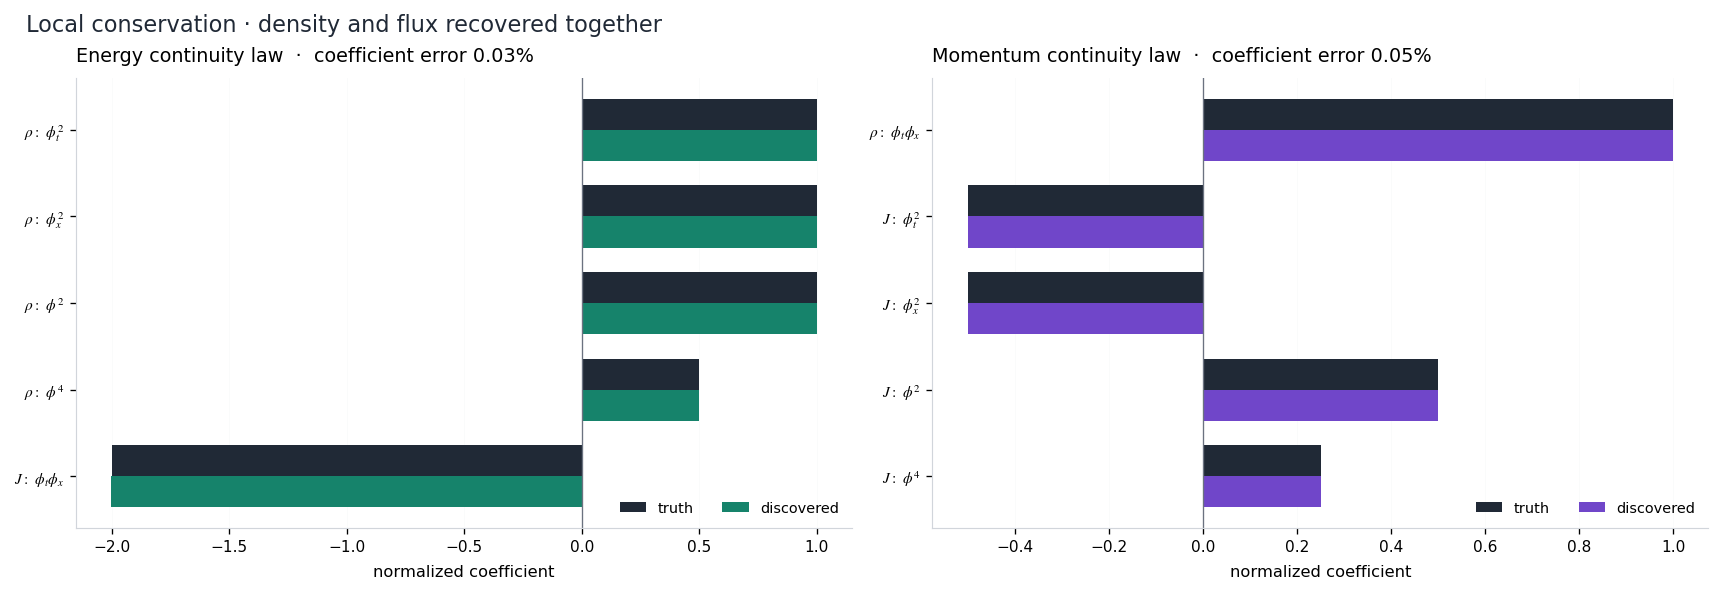

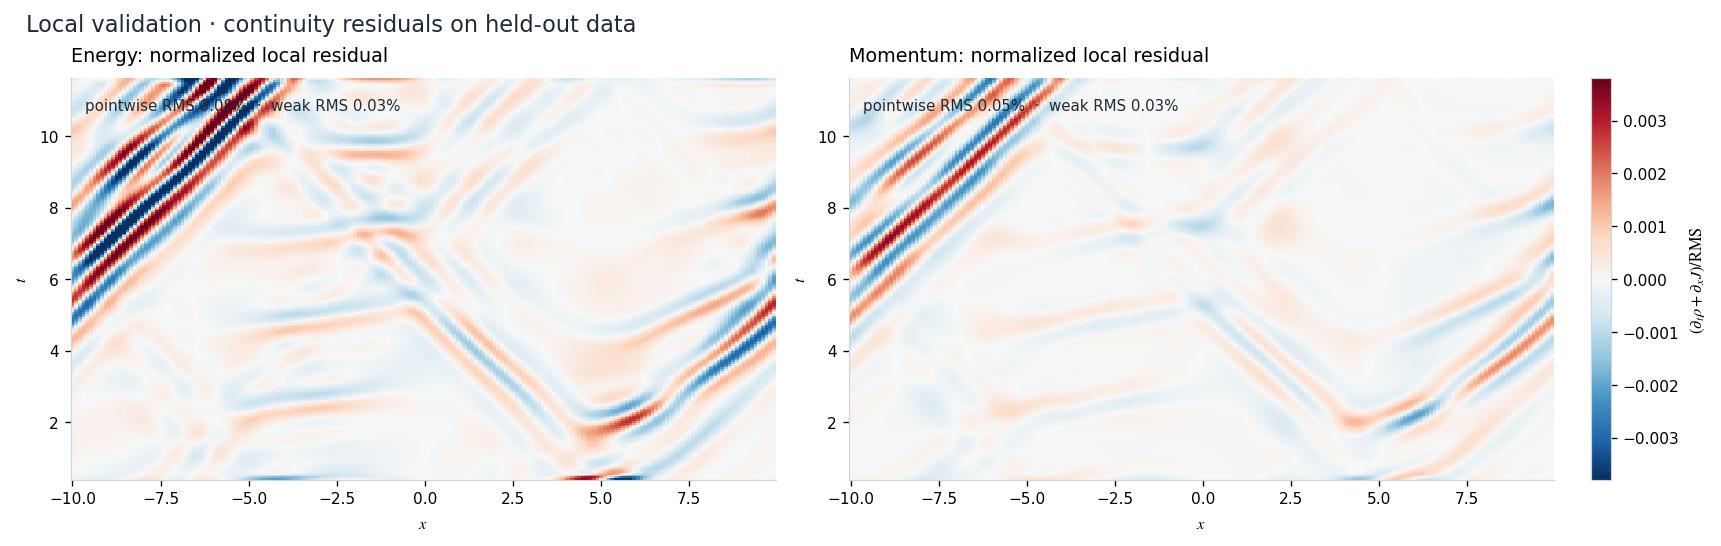

**Local-law scientific result.**
- Energy density–flux coefficient error: **0.033%**.
- Momentum density–flux coefficient error: **0.046%**.
- Held-out weak continuity residuals: energy **0.029%**, momentum **0.029%**.
- Local SVD third-to-second singular-value gap: **508.4×**.
- The coefficient graphs test whether the correct density and flux terms are selected; the residual maps test whether the learned law balances locally at each spacetime region.
- A globally conserved integral with a large local residual would fail this stronger test.

**Local-law scientific result.**
- Energy density–flux coefficient error: **0.033%**.
- Momentum density–flux coefficient error: **0.046%**.
- Held-out weak continuity residuals: energy **0.029%**, momentum **0.029%**.
- Local SVD third-to-second singular-value gap: **508.4×**.
- The coefficient graphs test whether the correct density and flux terms are selected; the residual maps test whether the learned law balances locally at each spacetime region.
- A globally conserved integral with a large local residual would fail this stronger test.

In [13]:
LOCAL_TERMS = [
    r"$\phi_t^2$", r"$\phi_x^2$", r"$\phi^2$", r"$\phi^4$",
    r"$\phi^6$", r"$\phi_t\phi_x$", r"$\phi\phi_t$", r"$\phi_x^4$",
]
N_LOCAL = len(LOCAL_TERMS)

# The coefficient vectors are normalized by rho_E[pi^2]=1 and rho_P[pi*phi_x]=1.
TRUE_LOCAL_ENERGY = np.concatenate([
    np.array([1.0, 1.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0]),
    np.array([0.0, 0.0, 0.0, 0.0, 0.0, -2.0, 0.0, 0.0]),
])
TRUE_LOCAL_MOMENTUM = np.concatenate([
    np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]),
    np.array([-0.5, -0.5, 0.5, 0.25, 0.0, 0.0, 0.0, 0.0]),
])

def local_candidate_fields(phi_observed):
    # Reuse field-only smoothing and first-derivative estimation.
    _, smooth, pi_est, phi_x_est = charge_library_from_observations(phi_observed)
    fields = np.stack([
        pi_est**2,
        phi_x_est**2,
        smooth**2,
        smooth**4,
        smooth**6,
        pi_est*phi_x_est,
        smooth*pi_est,
        phi_x_est**4,
    ], axis=-1)
    return fields, smooth, pi_est, phi_x_est

def local_continuity_library(phi_observed, windows_per_trajectory=520,
                             seed=0, half_t=9, half_x=11):
    fields, _, _, _ = local_candidate_fields(phi_observed)
    local_rng = np.random.default_rng(seed)
    bt, bt1, _ = compact_bump(half_t, DT_OBS)
    bx, bx1, _ = compact_bump(half_x, DX)
    psi_t = np.outer(bt1, bx)
    psi_x = np.outer(bt, bx1)
    volume = DT_OBS * DX

    rows = []
    n_time, n_space = fields.shape[1:3]
    offsets_x = np.arange(-half_x, half_x+1)
    for trajectory in fields:
        centers_t = local_rng.integers(half_t, n_time-half_t,
                                       size=windows_per_trajectory)
        centers_x = local_rng.integers(0, n_space,
                                       size=windows_per_trajectory)
        for ct, cx in zip(centers_t, centers_x):
            tidx = slice(ct-half_t, ct+half_t+1)
            xidx = (cx + offsets_x) % n_space
            patch = trajectory[tidx][:, xidx, :]
            density_columns = np.sum(patch*psi_t[..., None], axis=(0, 1))
            flux_columns = np.sum(patch*psi_x[..., None], axis=(0, 1))
            rows.append(np.concatenate([density_columns, flux_columns]))
    return volume*np.asarray(rows)

def refine_local_support(W, support):
    support = np.asarray(support, dtype=int)
    A = W[:, support]
    scale = np.linalg.norm(A, axis=0)
    scale[scale < 1e-14] = 1.0
    _, _, Vt = np.linalg.svd(A/scale, full_matrices=False)
    coef = np.zeros(W.shape[1])
    coef[support] = Vt[-1]/scale
    return coef

def discover_local_continuity_laws(W, rotation_points=12000, cutoff=0.045):
    # SVD returns the two-dimensional approximate continuity-law subspace.
    scale = np.linalg.norm(W, axis=0)
    scale[scale < 1e-14] = 1.0
    _, singular_values, Vt = np.linalg.svd(W/scale, full_matrices=False)
    basis = Vt[-2:]

    # Search rotations of the two-dimensional subspace for the sparsest pair.
    best_score, best_pair = np.inf, None
    for theta in np.linspace(0, np.pi, rotation_points, endpoint=False):
        c, s = np.cos(theta), np.sin(theta)
        candidates = [(c*basis[0]+s*basis[1])/scale,
                      (-s*basis[0]+c*basis[1])/scale]
        normalized = [v/np.max(np.abs(v)) for v in candidates]
        supports = [np.flatnonzero(np.abs(v) >= cutoff) for v in normalized]
        if any(len(supp) == 0 for supp in supports):
            continue
        if any((np.sum(supp < N_LOCAL) == 0 or
                np.sum(supp >= N_LOCAL) == 0) for supp in supports):
            continue
        score = (sum(len(supp) for supp in supports)
                 + 0.015*sum(np.sum(np.abs(v)) for v in normalized))
        if score < best_score:
            best_score, best_pair = score, supports

    if best_pair is None:
        raise RuntimeError("No density–flux sparse rotation was found")
    laws = [refine_local_support(W, supp) for supp in best_pair]

    # The energy law contains rho[pi^2]; the momentum law contains rho[pi*phi_x].
    energy_index = int(np.argmax([abs(v[0]) for v in laws]))
    momentum_index = 1-energy_index
    energy = laws[energy_index]/laws[energy_index][0]
    momentum = laws[momentum_index]/laws[momentum_index][5]
    energy[np.abs(energy) < 0.02] = 0.0
    momentum[np.abs(momentum) < 0.02] = 0.0
    return energy, momentum, singular_values

def local_weak_residual(W, coef):
    residual = W @ coef
    contribution_scale = np.sqrt(np.mean(np.sum((W*coef[None, :])**2, axis=1)))
    return np.sqrt(np.mean(residual**2)) / max(contribution_scale, 1e-14)

def local_residual_field(phi_observed_one, coef):
    fields, _, _, _ = local_candidate_fields(phi_observed_one)
    rho = np.tensordot(fields[0], coef[:N_LOCAL], axes=([-1], [0]))
    flux = np.tensordot(fields[0], coef[N_LOCAL:], axes=([-1], [0]))
    rho_t = savgol_filter(rho, 15, 5, deriv=1, delta=DT_OBS,
                          axis=0, mode="interp")
    flux_x = savgol_filter(flux, 13, 5, deriv=1, delta=DX,
                           axis=1, mode="wrap")
    residual = rho_t + flux_x
    scale = np.sqrt(np.mean(rho_t**2 + flux_x**2))
    return rho, flux, residual/max(scale, 1e-14)

W_local_train = local_continuity_library(phi_train, seed=SEED+810)
W_local_test = local_continuity_library(phi_test, seed=SEED+811)
local_energy_coef, local_momentum_coef, local_singular_values = (
    discover_local_continuity_laws(W_local_train)
)

local_energy_error = (np.linalg.norm(local_energy_coef-TRUE_LOCAL_ENERGY)
                      / np.linalg.norm(TRUE_LOCAL_ENERGY))
local_momentum_error = (np.linalg.norm(local_momentum_coef-TRUE_LOCAL_MOMENTUM)
                        / np.linalg.norm(TRUE_LOCAL_MOMENTUM))
local_energy_weak_residual = local_weak_residual(W_local_test, local_energy_coef)
local_momentum_weak_residual = local_weak_residual(W_local_test, local_momentum_coef)
local_gap = local_singular_values[-3]/max(local_singular_values[-2], 1e-15)

local_labels = ([rf"$\rho:$ {term}" for term in LOCAL_TERMS]
                + [rf"$J:$ {term}" for term in LOCAL_TERMS])
local_table = pd.DataFrame({
    "candidate": local_labels,
    "energy truth": TRUE_LOCAL_ENERGY,
    "energy discovered": local_energy_coef,
    "momentum truth": TRUE_LOCAL_MOMENTUM,
    "momentum discovered": local_momentum_coef,
})
display(local_table.style.format({c: "{:+.4f}" for c in local_table.columns[1:]}))

# Coefficient recovery: density and flux are learned in one joint null-space problem.
fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8), constrained_layout=True)
fig.suptitle("Local conservation · density and flux recovered together",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
local_labels_array = np.asarray(local_labels)
for ax, truth, learned, title, color, err in [
    (axes[0], TRUE_LOCAL_ENERGY, local_energy_coef,
     "Energy continuity law", COLORS["green"], local_energy_error),
    (axes[1], TRUE_LOCAL_MOMENTUM, local_momentum_coef,
     "Momentum continuity law", COLORS["purple"], local_momentum_error),
]:
    active = np.flatnonzero((np.abs(truth) > 1e-12) | (np.abs(learned) > 0.03))
    y_local = np.arange(len(active))
    ax.barh(y_local-0.18, truth[active], 0.36, color=COLORS["ink"], label="truth")
    ax.barh(y_local+0.18, learned[active], 0.36, color=color, label="discovered")
    ax.axvline(0, color=COLORS["gray"], lw=0.8)
    ax.set(title=f"{title}  ·  coefficient error {err:.2%}",
           xlabel="normalized coefficient")
    ax.set_yticks(y_local, local_labels_array[active])
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.18)
    ax.legend(loc="lower right", fontsize=8.7, ncol=2)
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("10_local_law_coefficients.png")
plt.show()

# Pointwise residuals are a stricter held-out test than global integration.
_, _, energy_residual_map = local_residual_field(phi_test[:1], local_energy_coef)
_, _, momentum_residual_map = local_residual_field(phi_test[:1], local_momentum_coef)
trim = slice(8, -8)
fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.4), constrained_layout=True)
fig.suptitle("Local validation · continuity residuals on held-out data",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])
residual_views = [energy_residual_map[trim], momentum_residual_map[trim]]
shared_limit = max([np.percentile(np.abs(view), 99) for view in residual_views] + [1e-6])
for ax, view, title, weak_resid in [
    (axes[0], residual_views[0], "Energy", local_energy_weak_residual),
    (axes[1], residual_views[1], "Momentum", local_momentum_weak_residual),
]:
    im = ax.pcolormesh(x, t_obs[trim], view, shading="auto", cmap="RdBu_r",
                       vmin=-shared_limit, vmax=shared_limit)
    pointwise_rms = np.sqrt(np.mean(view**2))
    ax.set(title=f"{title}: normalized local residual",
           xlabel="$x$", ylabel="$t$")
    ax.text(0.02, 0.95,
            f"pointwise RMS {pointwise_rms:.2%}  ·  weak RMS {weak_resid:.2%}",
            transform=ax.transAxes, va="top", fontsize=9.0,
            color=COLORS["ink"])
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
colorbar = fig.colorbar(im, ax=axes, fraction=0.032, pad=0.025)
colorbar.set_label(r"$(\partial_t\rho+\partial_xJ)/\mathrm{RMS}$")
savefig("11_local_continuity_residuals.png")
plt.show()

display(Markdown("\n".join([
    "**Local-law scientific result.**",
    f"- Energy density–flux coefficient error: **{local_energy_error:.3%}**.",
    f"- Momentum density–flux coefficient error: **{local_momentum_error:.3%}**.",
    f"- Held-out weak continuity residuals: energy **{local_energy_weak_residual:.3%}**, momentum **{local_momentum_weak_residual:.3%}**.",
    f"- Local SVD third-to-second singular-value gap: **{local_gap:.1f}×**.",
    "- The coefficient graphs test whether the correct density and flux terms are selected; the residual maps test whether the learned law balances locally at each spacetime region.",
    "- A globally conserved integral with a large local residual would fail this stronger test.",
])))

## 9. Noise robustness of the Noether discovery

The conservation-law algorithm sees only noisy $\phi(x,t)$. Both $\phi_t$ and $\phi_x$ are estimated from those observations. The learned charges are evaluated on independently noised held-out trajectories.

In [14]:
charge_records = []
start = time.perf_counter()
for noise in NOISE_LEVELS:
    for repeat in range(N_REPEATS):
        train_obs = noisy_copy(phi_train, noise, SEED+5000+43*repeat+int(1000*noise))
        test_obs = noisy_copy(phi_test, noise, SEED+7000+43*repeat+int(1000*noise))
        Q_train_noise, _, _, _ = charge_library_from_observations(train_obs)
        Q_test_noise, _, _, _ = charge_library_from_observations(test_obs)
        e_coef, p_coef, _ = discover_two_charges(Q_train_noise, rotation_points=6000)
        charge_records.append({
            "noise": noise,
            "repeat": repeat,
            "energy_coefficient_error": np.linalg.norm(e_coef-TRUE_ENERGY_COEF)/np.linalg.norm(TRUE_ENERGY_COEF),
            "momentum_coefficient_error": np.linalg.norm(p_coef-TRUE_MOMENTUM_COEF),
            "heldout_energy_drift": charge_drift(Q_test_noise, e_coef),
            "heldout_momentum_drift": charge_drift(Q_test_noise, p_coef),
            "energy_coefficients": e_coef,
            "momentum_coefficients": p_coef,
        })
charge_results = pd.DataFrame(charge_records)
print(f"Completed Noether noise study in {time.perf_counter()-start:.1f} s")

charge_summary = (charge_results.groupby("noise")
                  .agg(energy_error=("energy_coefficient_error", "mean"),
                       energy_drift=("heldout_energy_drift", "mean"),
                       momentum_error=("momentum_coefficient_error", "mean"),
                       momentum_drift=("heldout_momentum_drift", "mean"))
                  .reset_index())
display(charge_summary.style.format({
    "noise": "{:.0%}", "energy_error": "{:.3f}", "energy_drift": "{:.3e}",
    "momentum_error": "{:.3f}", "momentum_drift": "{:.3e}",
}))

Completed Noether noise study in 0.8 s


,noise,energy_error,energy_drift,momentum_error,momentum_drift
0,0%,0.000,7.684e-04,0.000,1.280e-03
1,1%,0.005,1.985e-02,0.000,8.615e-02
2,2%,0.017,4.482e-02,0.000,1.920e-01
3,5%,0.068,2.038e-01,0.000,4.291e-01
4,10%,255.463,5.613e+00,0.000,8.467e-01


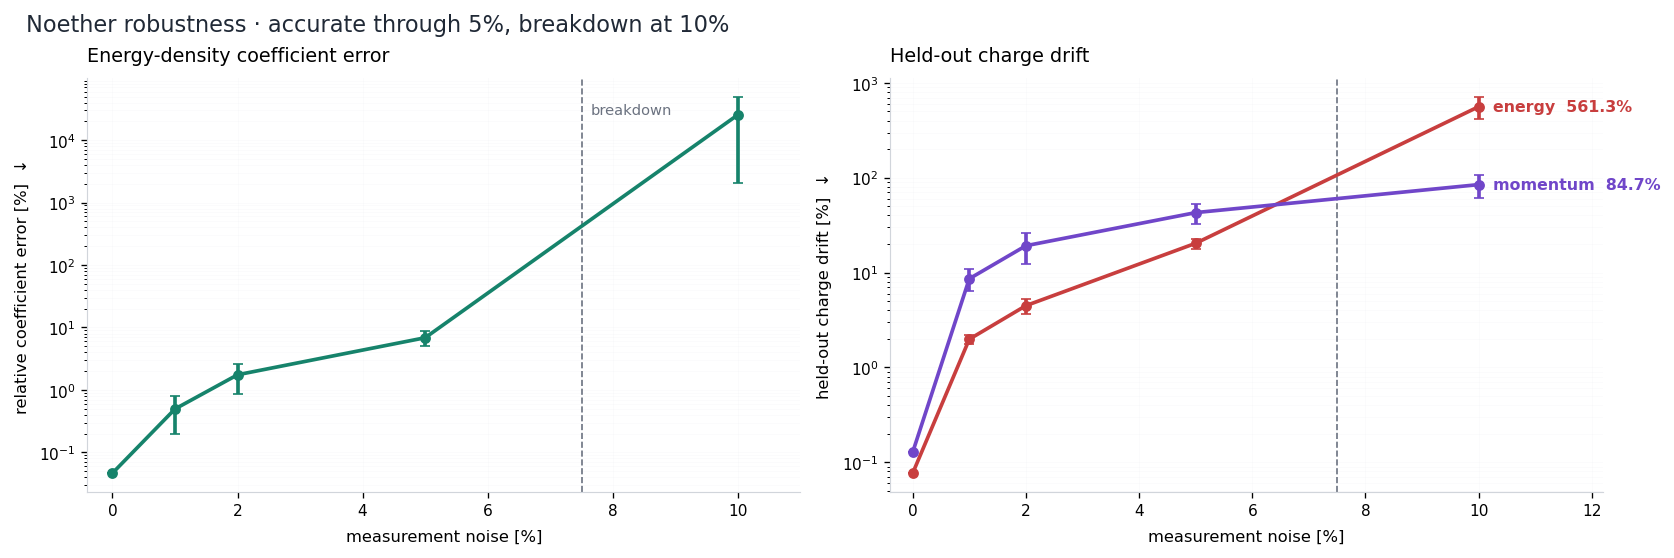

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.5), constrained_layout=True)
fig.suptitle("Noether robustness · accurate through 5%, breakdown at 10%",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])

energy_error_mean = (charge_results.groupby("noise").energy_coefficient_error
                     .mean().reindex(NOISE_LEVELS))
energy_error_std = (charge_results.groupby("noise").energy_coefficient_error
                    .std().reindex(NOISE_LEVELS).fillna(0))
energy_error_ci95 = ci95_from_std(energy_error_std, N_REPEATS)
axes[0].errorbar(100*NOISE_LEVELS, 100*energy_error_mean, yerr=100*energy_error_ci95,
                 marker="o", lw=2.2, capsize=3, color=COLORS["green"])
axes[0].set(title="Energy-density coefficient error",
            xlabel="measurement noise [%]", ylabel="relative coefficient error [%]  ↓",
            yscale="log", xlim=(-0.4, 11.0))

drift_specs = [
    ("heldout_energy_drift", "energy", COLORS["red"]),
    ("heldout_momentum_drift", "momentum", COLORS["purple"]),
]
for metric, label, color in drift_specs:
    means = charge_results.groupby("noise")[metric].mean().reindex(NOISE_LEVELS)
    stds = charge_results.groupby("noise")[metric].std().reindex(NOISE_LEVELS).fillna(0)
    ci95 = ci95_from_std(stds, N_REPEATS)
    means_pct = 100*means
    ci95_pct = 100*ci95
    axes[1].errorbar(100*NOISE_LEVELS, means_pct, yerr=ci95_pct, marker="o", lw=2.2,
                     capsize=3, color=color)
    axes[1].text(10.25, means_pct.iloc[-1], f"{label}  {means_pct.iloc[-1]:.1f}%", color=color,
                 va="center", fontsize=9.5, fontweight="bold")
axes[1].set(title="Held-out charge drift",
            xlabel="measurement noise [%]", ylabel="held-out charge drift [%]  ↓",
            yscale="log", xlim=(-0.4, 12.2))

for ax in axes:
    ax.axvline(7.5, color=COLORS["gray"], lw=1.0, ls="--")
    ax.grid(alpha=0.15, which="both")
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
axes[0].text(7.65, 0.94, "breakdown", transform=axes[0].get_xaxis_transform(),
             color=COLORS["gray"], fontsize=8.8, va="top")
savefig("07_noether_noise_robustness.png")
plt.show()

## 10. Independent-solver pseudo-experiment: an inverse-crime audit

A law-discovery result is less convincing if the data generator and the learner share the same numerical representation. This is the classical **inverse-crime** concern: recovery may be helped by discretization artifacts rather than by the continuum physics.

I therefore generate a completely separate dataset using numerical choices that are deliberately different from the main experiment:

$$
\text{finite-difference field solver}
\;\longrightarrow\;
\text{coarse sensor averaging}
\;\longrightarrow\;
\text{correlated noise + missing pixels}
\;\longrightarrow\;
\text{weak sparse discovery}.
$$

The hidden generator uses a 384-point, second-order finite-difference Laplacian and SciPy's adaptive eighth-order DOP853 time integrator. The learner receives only 96 spatial sensor averages at a lower frame rate. A fixed gain error, finite exposure time, space–time-correlated noise and missing measurements create a reproducible pseudo-experimental observation process. No spectral derivative, Verlet acceleration or exact simulator derivative is passed to the discovery code.

This is stronger than adding noise to data made by the original solver. It remains a **pseudo-experiment**, not a claim of laboratory validation.

In [16]:
# Independent data generator: finite differences in space and adaptive DOP853 in time.
IND_NX_FINE = 384
IND_N_SENSOR = 96
IND_T_FINAL = 8.0
IND_DT_FINE = 0.02
IND_DT_SENSOR = 2*IND_DT_FINE
IND_DX_FINE = LENGTH/IND_NX_FINE
IND_DX_SENSOR = LENGTH/IND_N_SENSOR
IND_N_TRAJECTORIES = 5

x_ind_fine = np.linspace(-LENGTH/2, LENGTH/2, IND_NX_FINE, endpoint=False)
t_ind_fine = np.arange(0.0, IND_T_FINAL + 0.5*IND_DT_FINE, IND_DT_FINE)
x_ind_sensor = x_ind_fine.reshape(IND_N_SENSOR, -1).mean(axis=1)
t_ind_sensor = 0.5*(t_ind_fine[:-1:2] + t_ind_fine[1::2])

def independent_initial_condition(seed):
    # Analytic random Fourier series: independent implementation and random draws.
    local_rng = np.random.default_rng(seed)
    phi = np.zeros_like(x_ind_fine)
    pi = np.zeros_like(x_ind_fine)
    phi_x_analytic = np.zeros_like(x_ind_fine)
    for mode in range(1, 7):
        wave_number = 2*np.pi*mode/LENGTH
        amplitude = local_rng.normal()*mode**-1.45
        phase = local_rng.uniform(0, 2*np.pi)
        velocity_amplitude = local_rng.normal()*mode**-1.45
        velocity_phase = local_rng.uniform(0, 2*np.pi)
        phi += amplitude*np.cos(wave_number*x_ind_fine + phase)
        phi_x_analytic += -amplitude*wave_number*np.sin(wave_number*x_ind_fine + phase)
        pi += velocity_amplitude*np.sin(wave_number*x_ind_fine + velocity_phase)

    phi -= phi.mean()
    pi -= pi.mean()
    field_scale = 0.68/np.sqrt(np.mean(phi**2))
    phi *= field_scale
    phi_x_analytic *= field_scale
    random_velocity = pi/np.sqrt(np.mean(pi**2))
    travelling_component = -phi_x_analytic/np.sqrt(np.mean(phi_x_analytic**2))
    pi = 0.65*random_velocity + 0.75*travelling_component
    pi -= pi.mean()
    pi *= 0.28/np.sqrt(np.mean(pi**2))
    return phi, pi

def simulate_independent_trajectory(seed):
    phi0, pi0 = independent_initial_condition(seed)

    def finite_difference_rhs(_, state):
        phi = state[:IND_NX_FINE]
        pi = state[IND_NX_FINE:]
        laplacian = (np.roll(phi, -1) - 2*phi + np.roll(phi, 1))/IND_DX_FINE**2
        acceleration = C**2*laplacian - MASS**2*phi - LAMBDA*phi**3
        return np.concatenate([pi, acceleration])

    solution = solve_ivp(
        finite_difference_rhs,
        (0.0, IND_T_FINAL),
        np.concatenate([phi0, pi0]),
        t_eval=t_ind_fine,
        method="DOP853",
        rtol=2e-9,
        atol=2e-11,
    )
    if not solution.success:
        raise RuntimeError(solution.message)
    phi = solution.y[:IND_NX_FINE].T
    pi = solution.y[IND_NX_FINE:].T
    return phi, pi

def finite_difference_energy(phi, pi):
    # Hamiltonian consistent with the second-order periodic spatial discretization.
    forward_gradient = (np.roll(phi, -1, axis=1) - phi)/IND_DX_FINE
    density = (0.5*pi**2 + 0.5*C**2*forward_gradient**2
               + 0.5*MASS**2*phi**2 + 0.25*LAMBDA*phi**4)
    return IND_DX_FINE*np.sum(density, axis=1)

ind_start = time.perf_counter()
independent_simulations = [
    simulate_independent_trajectory(SEED + 900 + trajectory)
    for trajectory in range(IND_N_TRAJECTORIES)
]
phi_ind_fine = np.asarray([simulation[0] for simulation in independent_simulations])
pi_ind_fine = np.asarray([simulation[1] for simulation in independent_simulations])
ind_energy = np.asarray([
    finite_difference_energy(phi, pi)
    for phi, pi in zip(phi_ind_fine, pi_ind_fine)
])
ind_relative_energy_drift = np.max(
    np.abs(ind_energy - ind_energy[:, :1])/np.maximum(np.abs(ind_energy[:, :1]), 1e-14)
)
print(f"Generated {IND_N_TRAJECTORIES} independent trajectories in "
      f"{time.perf_counter()-ind_start:.2f} s")
print(f"Maximum finite-difference energy drift: {ind_relative_energy_drift:.2e}")

Generated 5 independent trajectories in 0.14 s
Maximum finite-difference energy drift: 2.94e-09


In [17]:
def pseudo_sensor_operator(field, noise_fraction=0.0, missing_fraction=0.0, seed=0):
    # Coarse cell/exposure average, gain error, correlated noise and missing samples.
    if field.shape[1] % IND_N_SENSOR != 0:
        raise ValueError("Fine grid must be divisible by the sensor grid")
    local_rng = np.random.default_rng(seed)
    cells_per_sensor = field.shape[1]//IND_N_SENSOR
    cell_average = field.reshape(len(field), IND_N_SENSOR, cells_per_sensor).mean(axis=2)
    exposure_average = 0.5*(cell_average[:-1:2] + cell_average[1::2])

    # Static pixel-to-pixel gain calibration error (0.2%).
    sensor_gain = 1.0 + 0.002*local_rng.normal(size=IND_N_SENSOR)
    measured = exposure_average*sensor_gain[None, :]

    # Smooth random error is correlated over neighboring frames and sensors.
    if noise_fraction > 0:
        correlated_noise = gaussian_filter(
            local_rng.normal(size=measured.shape),
            sigma=(1.0, 0.8), mode=("nearest", "wrap")
        )
        target_rms = noise_fraction*np.sqrt(np.mean(measured**2))
        correlated_noise *= target_rms/np.sqrt(np.mean(correlated_noise**2))
        measured = measured + correlated_noise

    observed_mask = local_rng.random(measured.shape) >= missing_fraction
    if missing_fraction > 0:
        # Normalized local interpolation is used only where the detector has no value.
        numerator = gaussian_filter(
            np.where(observed_mask, measured, 0.0),
            sigma=(0.8, 0.8), mode=("nearest", "wrap")
        )
        denominator = gaussian_filter(
            observed_mask.astype(float),
            sigma=(0.8, 0.8), mode=("nearest", "wrap")
        )
        interpolated = numerator/np.maximum(denominator, 1e-6)
        measured = np.where(observed_mask, measured, interpolated)
    return measured, observed_mask

def weak_library_on_grid(phi_observed, dt, dx, windows_per_trajectory=350,
                         seed=0, half_t=8, half_x=6):
    # Grid-agnostic weak library: the learner knows sensor spacing, not solver internals.
    local_rng = np.random.default_rng(seed)
    bt, _, bt2 = compact_bump(half_t, dt)
    bx, bx1, bx2 = compact_bump(half_x, dx)
    psi = np.outer(bt, bx)
    psi_tt = np.outer(bt2, bx)
    psi_x = np.outer(bt, bx1)
    psi_xx = np.outer(bt, bx2)
    volume = dt*dx

    rows, targets = [], []
    offsets_x = np.arange(-half_x, half_x+1)
    for trajectory in phi_observed:
        centers_t = local_rng.integers(
            half_t, trajectory.shape[0]-half_t, size=windows_per_trajectory
        )
        centers_x = local_rng.integers(
            0, trajectory.shape[1], size=windows_per_trajectory
        )
        for center_t, center_x in zip(centers_t, centers_x):
            time_slice = slice(center_t-half_t, center_t+half_t+1)
            space_index = (center_x + offsets_x) % trajectory.shape[1]
            patch = trajectory[time_slice][:, space_index]
            rows.append([
                np.sum(psi),
                np.sum(patch*psi),
                np.sum(patch**2*psi),
                np.sum(patch**3*psi),
                np.sum(patch**5*psi),
                -np.sum(patch*psi_x),
                np.sum(patch*psi_xx),
            ])
            targets.append(np.sum(patch*psi_tt))
    return volume*np.asarray(rows), volume*np.asarray(targets)

ind_stage_specs = [
    ("coarse averaging", 0.00, 0.00),
    ("+ 2% correlated noise", 0.02, 0.00),
    ("+ noise + 8% missing", 0.02, 0.08),
]
ind_stage_records = []
ind_stage_objects = {}

for stage_index, (stage, noise_fraction, missing_fraction) in enumerate(ind_stage_specs):
    stage_fields, stage_masks = [], []
    for trajectory, fine_field in enumerate(phi_ind_fine):
        measured, mask = pseudo_sensor_operator(
            fine_field,
            noise_fraction=noise_fraction,
            missing_fraction=missing_fraction,
            seed=SEED + 1200 + 17*trajectory,
        )
        stage_fields.append(measured)
        stage_masks.append(mask)
    stage_fields = np.asarray(stage_fields)
    stage_masks = np.asarray(stage_masks)

    # Whole trajectories are separated: 3 fit, 1 model-selection, 1 final test.
    A_fit_ind, b_fit_ind = weak_library_on_grid(
        stage_fields[:3], IND_DT_SENSOR, IND_DX_SENSOR, seed=SEED+1300
    )
    A_val_ind, b_val_ind = weak_library_on_grid(
        stage_fields[3:4], IND_DT_SENSOR, IND_DX_SENSOR, seed=SEED+1301
    )
    A_test_ind, b_test_ind = weak_library_on_grid(
        stage_fields[4:5], IND_DT_SENSOR, IND_DX_SENSOR,
        windows_per_trajectory=500, seed=SEED+1302
    )
    best_ind, _ = fit_sparse_path(
        A_fit_ind, b_fit_ind, A_val_ind, b_val_ind, tolerance=0.08
    )
    threshold_ind, coefficient_ind, validation_nmse_ind, support_size_ind = best_ind
    prediction_ind = A_test_ind @ coefficient_ind
    residual_sum_squares = np.sum((prediction_ind-b_test_ind)**2)
    total_sum_squares = np.sum((b_test_ind-b_test_ind.mean())**2)
    heldout_r2_ind = 1.0 - residual_sum_squares/max(total_sum_squares, 1e-14)
    heldout_relative_l2_ind = (
        np.linalg.norm(prediction_ind-b_test_ind)/max(np.linalg.norm(b_test_ind), 1e-14)
    )
    exact_support_ind = bool(np.array_equal(
        np.abs(coefficient_ind) >= 0.08, np.abs(TRUE_PDE_COEF) > 0
    ))
    ind_stage_records.append({
        "sensor stage": stage,
        "coefficient error": coefficient_error(coefficient_ind),
        "support F1": support_f1(coefficient_ind),
        "exact support": exact_support_ind,
        "held-out R²": heldout_r2_ind,
        "held-out relative L²": heldout_relative_l2_ind,
        "selected threshold": threshold_ind,
        "support size": support_size_ind,
        "missing fraction": np.mean(~stage_masks),
    })
    ind_stage_objects[stage] = {
        "fields": stage_fields, "masks": stage_masks,
        "coefficients": coefficient_ind,
        "test target": b_test_ind, "test prediction": prediction_ind,
        "validation NMSE": validation_nmse_ind,
    }

independent_results = pd.DataFrame(ind_stage_records)
display(independent_results.style.format({
    "coefficient error": "{:.3%}", "support F1": "{:.3f}",
    "held-out R²": "{:.6f}", "held-out relative L²": "{:.3%}",
    "selected threshold": "{:.3g}", "missing fraction": "{:.2%}",
}))

ind_final_stage = ind_stage_specs[-1][0]
ind_final = ind_stage_objects[ind_final_stage]
ind_final_coef = ind_final["coefficients"]
ind_final_error = float(independent_results.iloc[-1]["coefficient error"])
ind_final_r2 = float(independent_results.iloc[-1]["held-out R²"])
ind_final_rel_l2 = float(independent_results.iloc[-1]["held-out relative L²"])
ind_final_support = bool(independent_results.iloc[-1]["exact support"])
ind_missing_fraction = float(independent_results.iloc[-1]["missing fraction"])
ind_exact_support_count = int(independent_results["exact support"].sum())

print("Independent final equation:", format_equation(ind_final_coef))

,sensor stage,coefficient error,support F1,exact support,held-out R²,held-out relative L²,selected threshold,support size,missing fraction
0,coarse averaging,1.386%,1.000,True,0.999995,0.228%,0.0001,3,0.00%
1,+ 2% correlated noise,2.389%,1.000,True,0.947318,22.952%,0.0701,3,0.00%
2,+ noise + 8% missing,2.123%,1.000,True,0.947179,22.983%,0.0701,3,8.01%


Independent final equation: phi_tt = -0.9949 phi -1.0012 phi^3 +1.0364 phi_xx


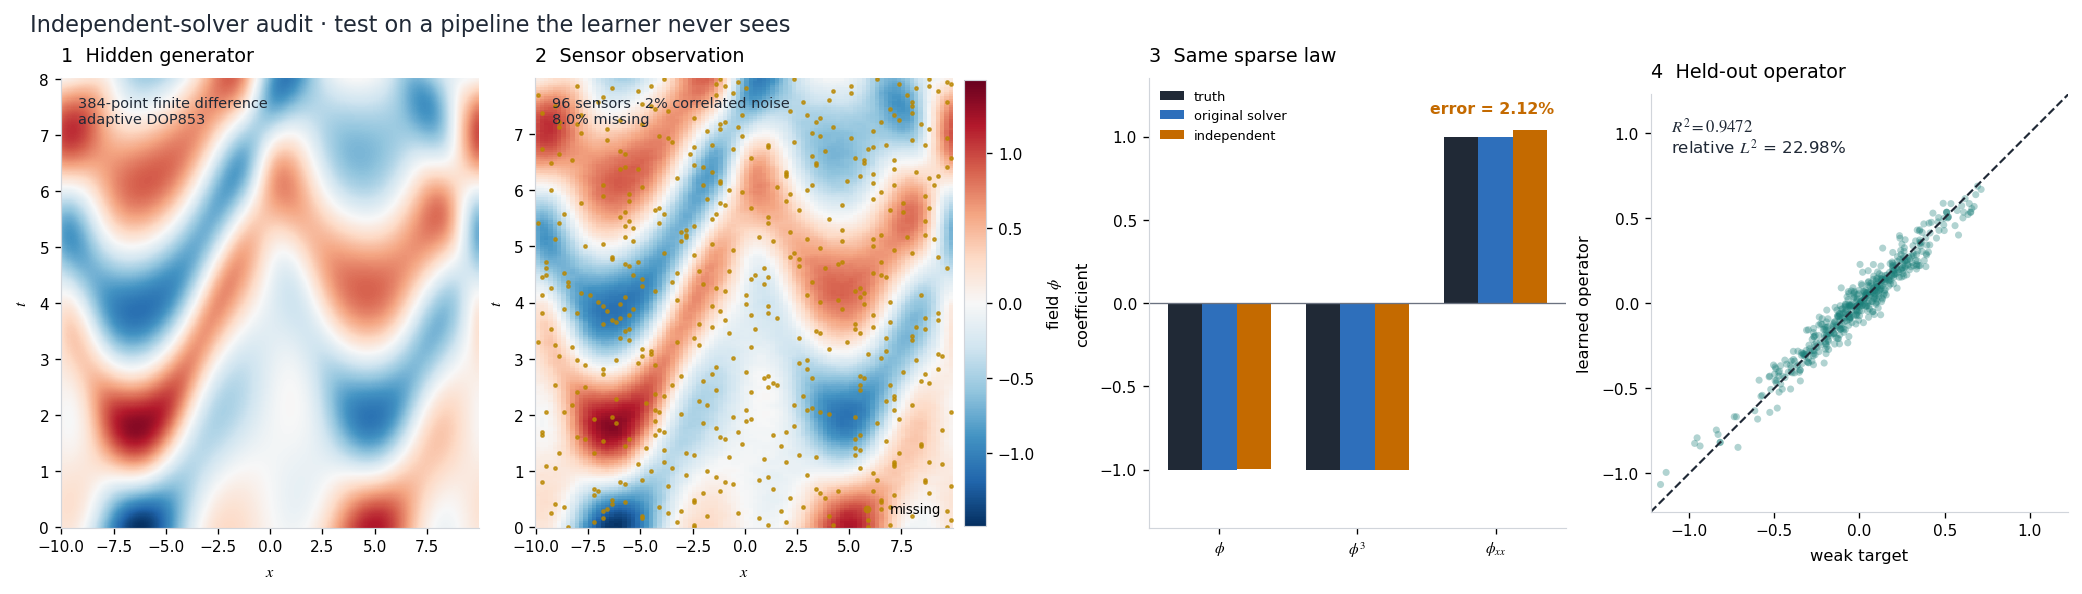

In [18]:
#  what is hidden, what is measured, and what is recovered.
final_fields = ind_final["fields"]
final_masks = ind_final["masks"]
final_target = ind_final["test target"]
final_prediction = ind_final["test prediction"]
common_limit = np.max(np.abs(phi_ind_fine[4]))

fig, axes = plt.subplots(1, 4, figsize=(17.2, 4.8), constrained_layout=True)
fig.suptitle("Independent-solver audit · test on a pipeline the learner never sees",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])

axes[0].pcolormesh(x_ind_fine, t_ind_fine, phi_ind_fine[4], shading="auto",
                   cmap="RdBu_r", vmin=-common_limit, vmax=common_limit)
axes[0].set(title="1  Hidden generator", xlabel="$x$", ylabel="$t$")
axes[0].text(0.04, 0.96, "384-point finite difference\nadaptive DOP853",
             transform=axes[0].transAxes, va="top", color=COLORS["ink"],
             fontsize=8.7)

im_sensor = axes[1].pcolormesh(
    x_ind_sensor, t_ind_sensor, final_fields[4], shading="auto",
    cmap="RdBu_r", vmin=-common_limit, vmax=common_limit
)
missing_t, missing_x = np.where(~final_masks[4])
show_missing = np.arange(0, len(missing_t), 3)
axes[1].scatter(x_ind_sensor[missing_x[show_missing]],
                t_ind_sensor[missing_t[show_missing]],
                s=3.5, color=COLORS["gold"], alpha=0.75, label="missing")
axes[1].set(title="2  Sensor observation", xlabel="$x$", ylabel="$t$")
axes[1].text(0.04, 0.96,
             f"96 sensors · 2% correlated noise\n{100*ind_missing_fraction:.1f}% missing",
             transform=axes[1].transAxes, va="top", color=COLORS["ink"],
             fontsize=8.7)
axes[1].legend(loc="lower right", fontsize=8, markerscale=2)
colorbar = fig.colorbar(im_sensor, ax=axes[:2], pad=0.012, fraction=0.025)
colorbar.set_label(r"field $\phi$")

coefficient_active = np.flatnonzero(np.abs(TRUE_PDE_COEF) > 1e-12)
coefficient_x = np.arange(len(coefficient_active))
coefficient_width = 0.25
axes[2].bar(coefficient_x-coefficient_width, TRUE_PDE_COEF[coefficient_active],
            coefficient_width, color=COLORS["ink"], label="truth")
axes[2].bar(coefficient_x, weak_clean_coef[coefficient_active], coefficient_width,
            color=COLORS["blue"], label="original solver")
axes[2].bar(coefficient_x+coefficient_width, ind_final_coef[coefficient_active],
            coefficient_width, color=COLORS["orange"], label="independent")
axes[2].axhline(0, color=COLORS["gray"], lw=0.8)
axes[2].set_xticks(coefficient_x, np.asarray(PDE_LABELS)[coefficient_active])
axes[2].set(title="3  Same sparse law", ylabel="coefficient",
            ylim=(-1.35, 1.35))
axes[2].legend(fontsize=7.8, loc="upper left")
axes[2].text(0.97, 0.95, f"error = {ind_final_error:.2%}",
             transform=axes[2].transAxes, ha="right", va="top",
             color=COLORS["orange"], fontsize=9.5, fontweight="bold")

scatter_stride = max(1, len(final_target)//800)
axes[3].scatter(final_target[::scatter_stride], final_prediction[::scatter_stride],
                s=18, alpha=0.34, color=COLORS["teal"], edgecolors="none")
operator_limit = 1.05*max(np.max(np.abs(final_target)),
                          np.max(np.abs(final_prediction)))
axes[3].plot([-operator_limit, operator_limit], [-operator_limit, operator_limit],
             ls="--", lw=1.3, color=COLORS["ink"])
axes[3].set(title="4  Held-out operator", xlabel="weak target",
            ylabel="learned operator", xlim=(-operator_limit, operator_limit),
            ylim=(-operator_limit, operator_limit))
axes[3].set_aspect("equal", adjustable="box")
axes[3].text(0.05, 0.95,
             rf"$R^2={ind_final_r2:.4f}$" + "\n" + rf"relative $L^2$ = {ind_final_rel_l2:.2%}",
             transform=axes[3].transAxes, va="top", color=COLORS["ink"],
             fontsize=10)

for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("12_independent_solver_pipeline.png")
plt.show()

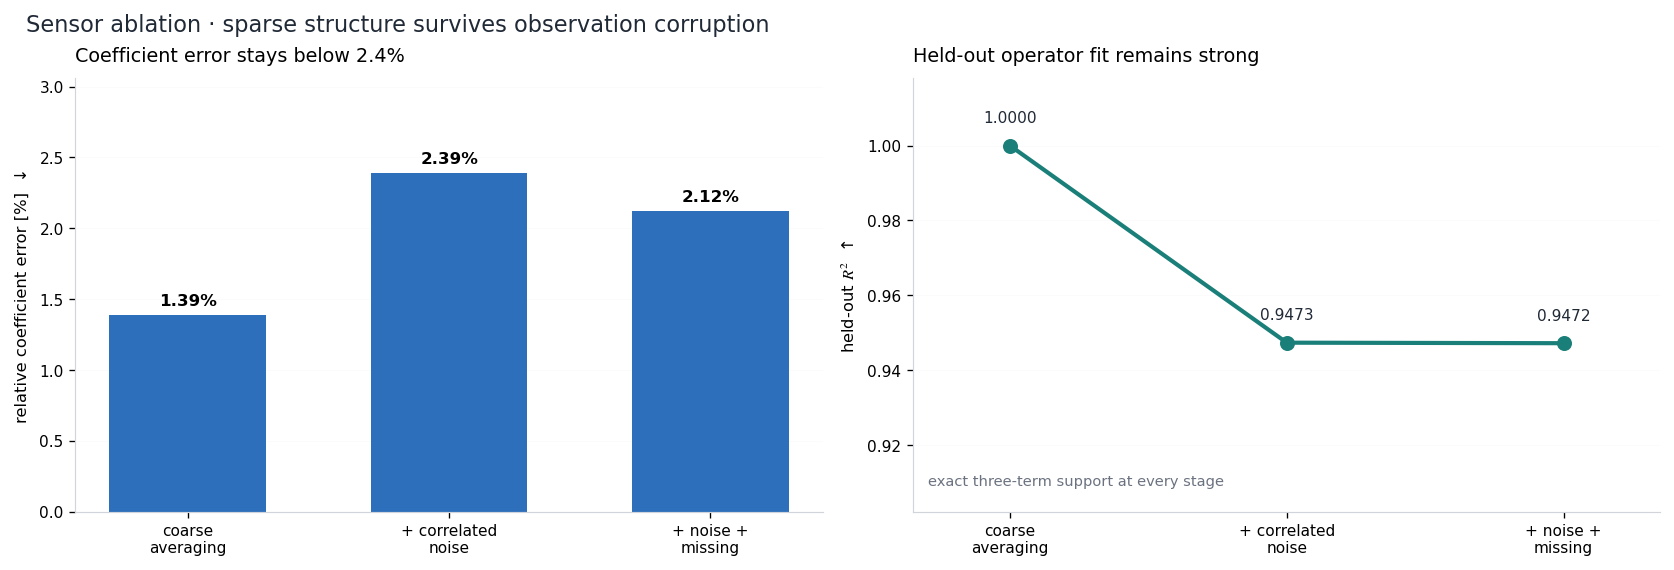

**Independent-solver scientific result.**
- The hidden finite-difference/DOP853 simulation has maximum energy drift **2.94e-09**.
- The correct three-term support is recovered in **3/3** sensor stages.
- With 2% correlated noise and **8.0%** missing measurements, coefficient error is **2.123%**.
- On the completely held-out fifth trajectory, the weak operator gives **$R^2=0.94718$** and relative $L^2$ error **22.983%**.
- The small non-monotonic error change after missing-value interpolation should not be read as evidence that missing data help: local interpolation also smooths part of this particular correlated-noise realization.
- Because the generator changes both spatial and temporal discretization, this result rules out the most obvious shared-solver inverse crime.
- It does not replace a laboratory experiment: sensor physics and model discrepancy are still idealized.

In [19]:
# controlled ablation of the observation process.
stage_positions = np.arange(len(independent_results))
stage_short_labels = ["coarse\naveraging", "+ correlated\nnoise", "+ noise +\nmissing"]
error_percent = 100*independent_results["coefficient error"].to_numpy()
r2_values = independent_results["held-out R²"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.6), constrained_layout=True)
fig.suptitle("Sensor ablation · sparse structure survives observation corruption",
             x=0.01, ha="left", fontsize=13.5, fontweight="medium", color=COLORS["ink"])

bars_error = axes[0].bar(stage_positions, error_percent,
                         color=COLORS["blue"], width=0.60)
axes[0].bar_label(bars_error, labels=[f"{value:.2f}%" for value in error_percent],
                  padding=4, fontsize=10, fontweight="bold")
axes[0].set_xticks(stage_positions, stage_short_labels)
axes[0].set(title="Coefficient error stays below 2.4%",
            ylabel="relative coefficient error [%]  ↓")
axes[0].set_ylim(0, 1.28*max(error_percent))
axes[0].grid(axis="y", alpha=0.15)

axes[1].plot(stage_positions, r2_values, "o-", lw=2.5, markersize=8,
             color=COLORS["teal"])
for position, value, exact in zip(stage_positions, r2_values,
                                  independent_results["exact support"]):
    axes[1].annotate(f"{value:.4f}",
                     (position, value), xytext=(0, 12), textcoords="offset points",
                     ha="center", va="bottom", fontsize=9.2,
                     color=COLORS["ink"])
lower_r2 = max(0.0, min(r2_values)-0.045)
axes[1].set_xticks(stage_positions, stage_short_labels)
axes[1].set(title="Held-out operator fit remains strong",
            ylabel=r"held-out $R^2$  ↑", ylim=(lower_r2, 1.018),
            xlim=(-0.35, len(stage_positions)-0.65))
axes[1].grid(axis="y", alpha=0.15)
axes[1].text(0.02, 0.06, "exact three-term support at every stage",
             transform=axes[1].transAxes, color=COLORS["gray"], fontsize=8.8)

for ax in axes:
    ax.title.set_ha("left")
    ax.title.set_position((0, 1.0))
savefig("13_independent_solver_ablation.png")
plt.show()

display(Markdown("\n".join([
    "**Independent-solver scientific result.**",
    f"- The hidden finite-difference/DOP853 simulation has maximum energy drift **{ind_relative_energy_drift:.2e}**.",
    f"- The correct three-term support is recovered in **{ind_exact_support_count}/{len(independent_results)}** sensor stages.",
    f"- With 2% correlated noise and **{ind_missing_fraction:.1%}** missing measurements, coefficient error is **{ind_final_error:.3%}**.",
    f"- On the completely held-out fifth trajectory, the weak operator gives **$R^2={ind_final_r2:.5f}$** and relative $L^2$ error **{ind_final_rel_l2:.3%}**.",
    "- The small non-monotonic error change after missing-value interpolation should not be read as evidence that missing data help: local interpolation also smooths part of this particular correlated-noise realization.",
    "- Because the generator changes both spatial and temporal discretization, this result rules out the most obvious shared-solver inverse crime.",
    "- It does not replace a laboratory experiment: sensor physics and model discrepancy are still idealized.",
])))

## 11. External and structure-aware discovery audits

The ordinary sparse-regression and PDE-FIND pipelines above are cross-checked with **PySINDy**; field inversion, spatial reflection and time reversal are encoded as hard library constraints; total-variation denoising is tested before strong differentiation; coordinate sampling tests compressed PDE-FIND; and a POD–Galerkin model inherits the Hamiltonian structure of the discovered equation.

### 11.1 PySINDy benchmark and symmetry-constrained SINDy

PySINDy is applied to the first-order representation $\phi_t=\pi$, $\pi_t=f(\phi,\pi)$. The auxiliary velocity is estimated from the measured field with a Savitzky–Golay derivative; no simulator acceleration is supplied. A custom feature library contains linear and cubic state terms plus first and second spatial derivatives. For the scalar acceleration, the discrete symmetries imply that only $\phi$, $\phi^3$, $\phi^5$ and $\phi_{xx}$ are admissible. Setting the forbidden coefficients to zero is the hard constraint $C\xi=0$.

,feature,ground truth,PySINDy
0,x0,-1.00000,-1.00079
1,x1,+0.00000,+0.00000
2,x0^3,-1.00000,-0.99977
3,x1^3,+0.00000,+0.00000
4,x0_1,+0.00000,+0.00000
5,x1_1,+0.00000,+0.00000
6,x0_11,+1.00000,+0.99798
7,x1_11,+0.00000,+0.00000


PySINDy 2.1.0: acceleration coefficient error 0.126%; held-out NMSE 5.29e-06
Symmetry screen: 7 -> 4 candidates; 10% noise error 0.999% -> 0.999%


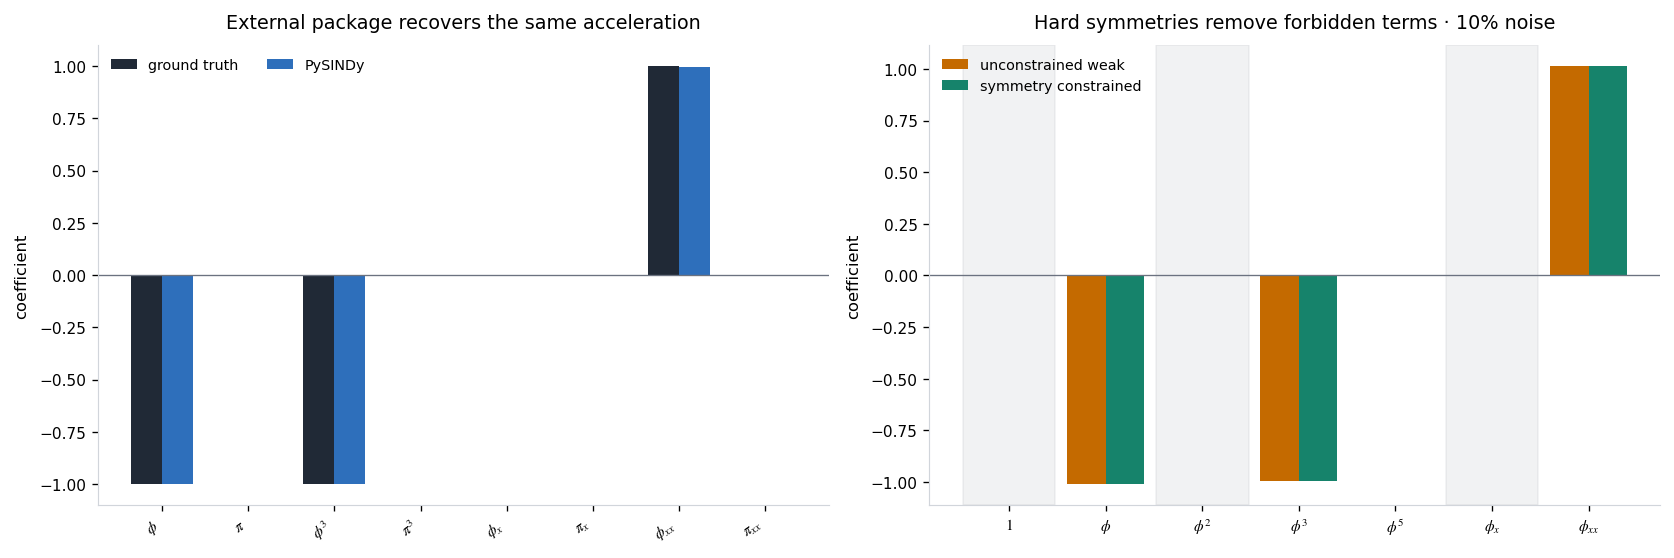

In [20]:
# Independent package benchmark: PySINDy on a first-order field representation.
PYSINDY_TIME_STRIDE = 4

def pysindy_first_order_data(phi_observed):
    # Estimate pi and pi_t from phi only, then arrange data as (space, time, state).
    smooth = savgol_filter(phi_observed, 17, 5, axis=0, mode="interp")
    pi_est = savgol_filter(phi_observed, 17, 5, deriv=1, delta=DT_OBS,
                            axis=0, mode="interp")
    pi_t_est = savgol_filter(phi_observed, 17, 5, deriv=2, delta=DT_OBS,
                              axis=0, mode="interp")
    take = slice(None, None, PYSINDY_TIME_STRIDE)
    state = np.stack([smooth[take].T, pi_est[take].T], axis=-1)
    state_dot = np.stack([pi_est[take].T, pi_t_est[take].T], axis=-1)
    return state, state_dot

pysindy_function_library = ps.CustomLibrary(
    library_functions=[lambda q: q, lambda q: q**3],
    function_names=[lambda q: q, lambda q: q + "^3"],
    interaction_only=True, include_bias=False,
)
pysindy_pde_library = ps.PDELibrary(
    function_library=pysindy_function_library,
    derivative_order=2, spatial_grid=x, include_bias=False,
    include_interaction=False, differentiation_method=ps.FiniteDifference,
    diff_kwargs={"order": 4, "is_uniform": True, "periodic": True},
)
pysindy_optimizer = ps.STLSQ(
    threshold=0.05, alpha=1e-8, normalize_columns=True, max_iter=100
)
pysindy_model = ps.SINDy(feature_library=pysindy_pde_library,
                           optimizer=pysindy_optimizer)
pysindy_train = [pysindy_first_order_data(field) for field in phi_train[:3]]
pysindy_model.fit(
    [item[0] for item in pysindy_train],
    t=DT_OBS*PYSINDY_TIME_STRIDE,
    x_dot=[item[1] for item in pysindy_train],
)

pysindy_feature_names = np.asarray(pysindy_model.get_feature_names())
pysindy_coefficients = pysindy_model.coefficients()
pysindy_acceleration_coef = pysindy_coefficients[1]
pysindy_true_acceleration = np.array([-1.0, 0.0, -1.0, 0.0,
                                      0.0, 0.0, 1.0, 0.0])
pysindy_acceleration_error = (
    np.linalg.norm(pysindy_acceleration_coef-pysindy_true_acceleration)
    / np.linalg.norm(pysindy_true_acceleration)
)
pysindy_validation_state, pysindy_validation_target = pysindy_first_order_data(phi_train[5])
pysindy_test_state, pysindy_test_target = pysindy_first_order_data(phi_test[0])
pysindy_validation_prediction = np.asarray(pysindy_model.predict(pysindy_validation_state))
pysindy_test_prediction = np.asarray(pysindy_model.predict(pysindy_test_state))
pysindy_validation_nmse = (
    np.mean((pysindy_validation_prediction-pysindy_validation_target)**2)
    / np.mean((pysindy_validation_target-pysindy_validation_target.mean(axis=(0, 1)))**2)
)
pysindy_test_nmse = (
    np.mean((pysindy_test_prediction-pysindy_test_target)**2)
    / np.mean((pysindy_test_target-pysindy_test_target.mean(axis=(0, 1)))**2)
)

# Symmetry constraints on the original seven-term weak library.
SYMMETRY_ALLOWED = np.array([False, True, False, True, True, False, True])
symmetry_observed = noisy_copy(phi_train, 0.10, SEED+1100)
A_sym_fit, b_sym_fit = weak_library(symmetry_observed[:5], seed=SEED+100)
A_sym_val, b_sym_val = weak_library(symmetry_observed[5:6], seed=SEED+200)
symmetry_full_best, _ = fit_sparse_path(A_sym_fit, b_sym_fit,
                                         A_sym_val, b_sym_val)
symmetry_reduced_best, _ = fit_sparse_path(
    A_sym_fit[:, SYMMETRY_ALLOWED], b_sym_fit,
    A_sym_val[:, SYMMETRY_ALLOWED], b_sym_val,
)
symmetry_constrained_coef = np.zeros(len(PDE_TERMS))
symmetry_constrained_coef[SYMMETRY_ALLOWED] = symmetry_reduced_best[1]
symmetry_full_error = coefficient_error(symmetry_full_best[1])
symmetry_constrained_error = coefficient_error(symmetry_constrained_coef)
symmetry_constraint_violation = float(
    np.max(np.abs(symmetry_constrained_coef[~SYMMETRY_ALLOWED]))
)

pysindy_table = pd.DataFrame({
    "feature": pysindy_feature_names,
    "ground truth": pysindy_true_acceleration,
    "PySINDy": pysindy_acceleration_coef,
})
display(pysindy_table.style.format({"ground truth": "{:+.5f}",
                                    "PySINDy": "{:+.5f}"}))
print(f"PySINDy {ps.__version__}: acceleration coefficient error "
      f"{pysindy_acceleration_error:.3%}; held-out NMSE {pysindy_test_nmse:.2e}")
print(f"Symmetry screen: {len(PDE_TERMS)} -> {SYMMETRY_ALLOWED.sum()} candidates; "
      f"10% noise error {symmetry_full_error:.3%} -> {symmetry_constrained_error:.3%}")

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.5), constrained_layout=True)
feature_labels = [r"$\phi$", r"$\pi$", r"$\phi^3$", r"$\pi^3$",
                  r"$\phi_x$", r"$\pi_x$", r"$\phi_{xx}$", r"$\pi_{xx}$"]
positions = np.arange(len(feature_labels))
axes[0].bar(positions-0.18, pysindy_true_acceleration, 0.36,
            color=COLORS["ink"], label="ground truth")
axes[0].bar(positions+0.18, pysindy_acceleration_coef, 0.36,
            color=COLORS["blue"], label="PySINDy")
axes[0].set_xticks(positions, feature_labels, rotation=35, ha="right")
axes[0].set(title="External package recovers the same acceleration",
            ylabel="coefficient")
axes[0].axhline(0, color=COLORS["gray"], lw=0.8)
axes[0].legend(ncol=2)

positions = np.arange(len(PDE_TERMS))
axes[1].bar(positions-0.20, symmetry_full_best[1], 0.40,
            color=COLORS["orange"], label="unconstrained weak")
axes[1].bar(positions+0.20, symmetry_constrained_coef, 0.40,
            color=COLORS["green"], label="symmetry constrained")
for index in np.flatnonzero(~SYMMETRY_ALLOWED):
    axes[1].axvspan(index-0.48, index+0.48, color=COLORS["gray"], alpha=0.09)
axes[1].set_xticks(positions, PDE_LABELS)
axes[1].set(title="Hard symmetries remove forbidden terms · 10% noise",
            ylabel="coefficient")
axes[1].axhline(0, color=COLORS["gray"], lw=0.8)
axes[1].legend(ncol=1)
savefig("14_pysindy_and_symmetry.png")
plt.show()

### 11.2 TV-stabilized derivatives and compressed PDE-FIND

The strong pipeline is repeated at 10% measurement noise after one-dimensional total-variation denoising of every temporal sensor trace. The TV weight is restricted to a modest preregistered grid (0–8% of the field standard deviation) to expose the bias–variance trade-off. Separately, the noisy weak library is left-multiplied by a coordinate-sampling matrix $C$: retaining a fraction of its rows is exactly the compressed regression $C\Theta\xi=C\phi_{tt}$. Thirty independent samplings quantify the probability of exact support recovery.

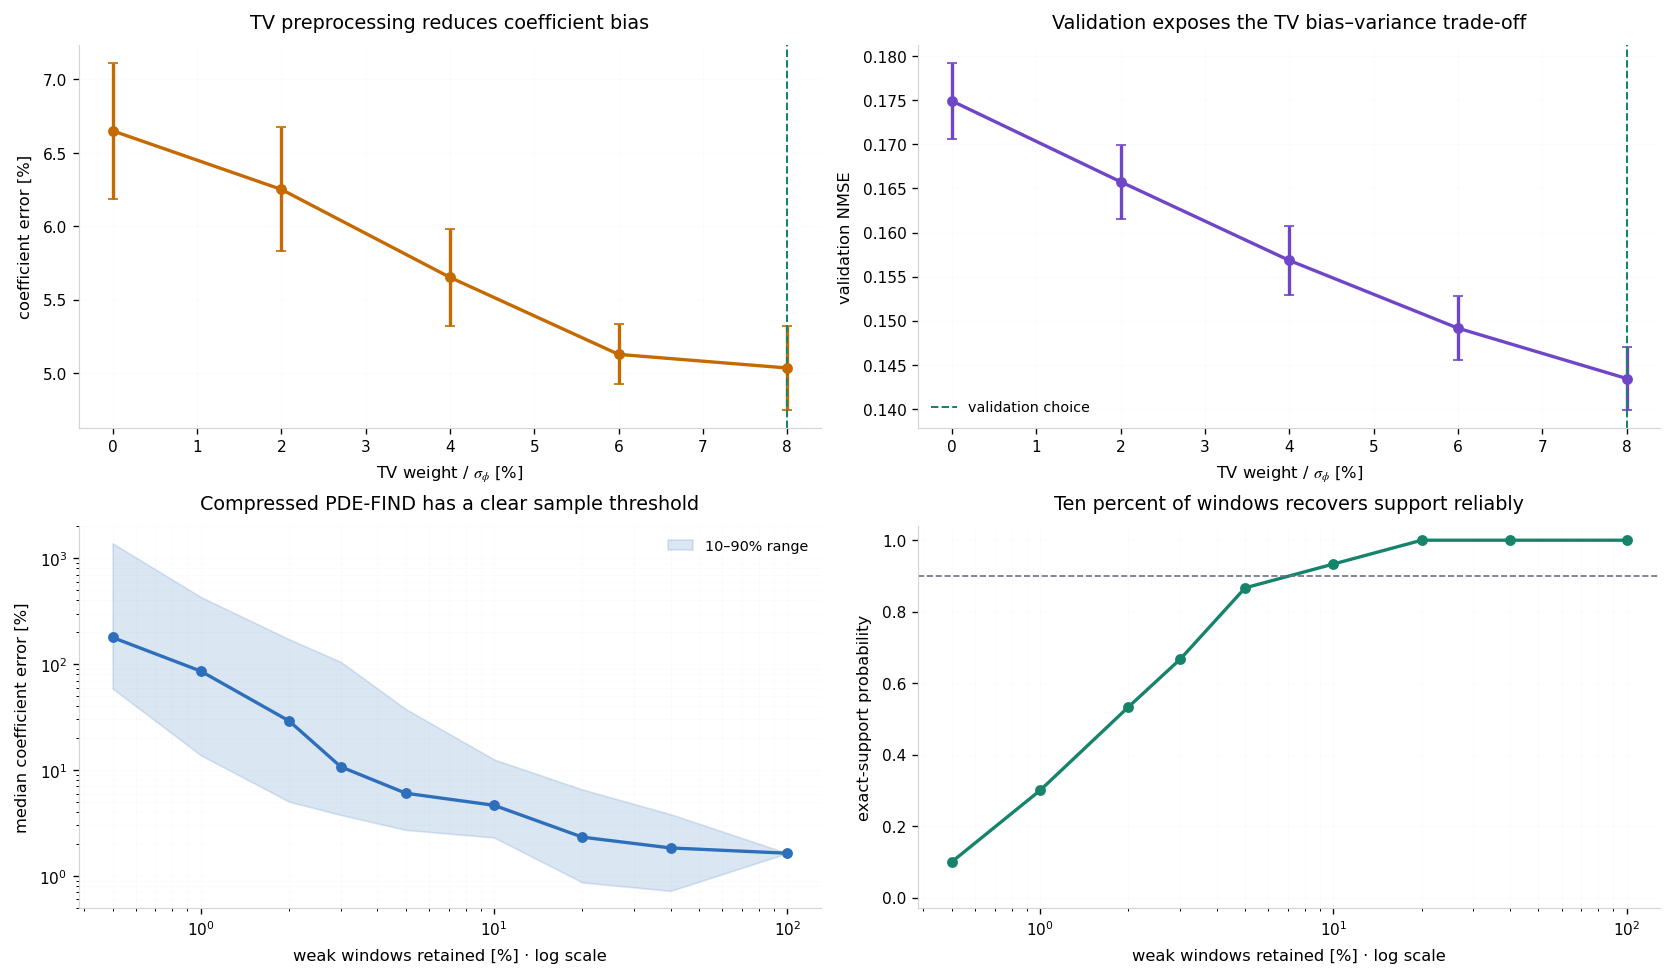

,relative_weight,coefficient_error_mean,coefficient_error_std,validation_NMSE_mean,validation_NMSE_std,support_F1_mean
0,0.0%,6.650%,0.464%,1.749e-01,4.347e-03,1.000
1,2.0%,6.250%,0.422%,1.658e-01,4.208e-03,1.000
2,4.0%,5.651%,0.333%,1.568e-01,3.900e-03,1.000
3,6.0%,5.126%,0.204%,1.491e-01,3.665e-03,1.000
4,8.0%,5.033%,0.288%,1.434e-01,3.595e-03,1.000


,fraction,rows,median_error,error_p10,error_p90,exact_support_probability
0,0.5%,8,178.447%,58.810%,1381.925%,10.0%
1,1.0%,13,85.759%,13.775%,429.738%,30.0%
2,2.0%,26,29.050%,5.026%,171.535%,53.3%
3,3.0%,39,10.733%,3.766%,104.932%,66.7%
4,5.0%,65,6.037%,2.719%,37.581%,86.7%
5,10.0%,130,4.644%,2.305%,12.574%,93.3%
6,20.0%,260,2.324%,0.869%,6.549%,100.0%
7,40.0%,520,1.838%,0.723%,3.825%,100.0%
8,100.0%,1300,1.638%,1.638%,1.638%,100.0%


In [21]:
# Total-variation preprocessing before the noise-sensitive strong formulation.
TV_RELATIVE_WEIGHTS = np.array([0.00, 0.02, 0.04, 0.06, 0.08])
TV_REPEATS = 6

def tv_denoise_1d(signal, weight, eps=2e-4, max_iter=80):
    # Chambolle's dual algorithm for the 1D Rudin–Osher–Fatemi problem.
    if weight <= 0:
        return signal.copy()
    dual = np.zeros_like(signal)
    gradient = np.zeros_like(signal)
    negative_divergence = np.zeros_like(signal)
    previous_energy = initial_energy = None
    for iteration in range(max_iter):
        if iteration > 0:
            negative_divergence = -dual.copy()
            negative_divergence[1:] += dual[:-1]
            output = signal + negative_divergence
        else:
            output = signal.copy()
        energy = np.sum(negative_divergence**2)
        gradient[:-1] = np.diff(output)
        gradient[-1] = 0.0
        norm = np.abs(gradient)
        energy += weight*np.sum(norm)
        dual -= 0.5*gradient
        dual /= 1.0 + 0.5*norm/weight
        energy /= signal.size
        if iteration == 0:
            initial_energy = previous_energy = energy
        elif abs(previous_energy-energy) < eps*initial_energy:
            break
        else:
            previous_energy = energy
    return output

def tv_denoise_time_traces(field, relative_weight):
    if relative_weight <= 0:
        return field.copy()
    filtered = np.empty_like(field)
    absolute_weight = relative_weight * field_scale
    for trajectory in range(field.shape[0]):
        for sensor in range(field.shape[2]):
            filtered[trajectory, :, sensor] = tv_denoise_1d(
                field[trajectory, :, sensor], weight=absolute_weight
            )
    return filtered

tv_records = []
for relative_weight in TV_RELATIVE_WEIGHTS:
    for repeat in range(TV_REPEATS):
        observed = noisy_copy(phi_train, 0.10, SEED+15000+repeat)
        filtered = tv_denoise_time_traces(observed, relative_weight)
        A_tv_fit, b_tv_fit = strong_library(filtered[:5], seed=SEED+repeat)
        A_tv_val, b_tv_val = strong_library(
            filtered[5:6], max_rows=35_000, seed=SEED+50+repeat
        )
        tv_best, _ = fit_sparse_path(A_tv_fit, b_tv_fit, A_tv_val, b_tv_val)
        tv_records.append({
            "relative_weight": relative_weight,
            "repeat": repeat,
            "coefficient_error": coefficient_error(tv_best[1]),
            "support_F1": support_f1(tv_best[1]),
            "validation_NMSE": tv_best[2],
        })
tv_results = pd.DataFrame(tv_records)
tv_summary = (tv_results.groupby("relative_weight")
              .agg(coefficient_error_mean=("coefficient_error", "mean"),
                   coefficient_error_std=("coefficient_error", "std"),
                   validation_NMSE_mean=("validation_NMSE", "mean"),
                   validation_NMSE_std=("validation_NMSE", "std"),
                   support_F1_mean=("support_F1", "mean"))
              .reset_index())
tv_selected_row = tv_summary.sort_values(
    ["validation_NMSE_mean", "relative_weight"]
).iloc[0]
tv_baseline_row = tv_summary[np.isclose(tv_summary.relative_weight, 0.0)].iloc[0]
tv_baseline_error = float(tv_baseline_row.coefficient_error_mean)
tv_selected_error = float(tv_selected_row.coefficient_error_mean)
tv_selected_relative_weight = float(tv_selected_row.relative_weight)

# Compressed PDE-FIND: coordinate sampling of a 10%-noise weak library.
compression_observed = noisy_copy(phi_train, 0.10, SEED+12345)
A_compression_fit, b_compression_fit = weak_library(
    compression_observed[:5], seed=SEED
)
A_compression_val, b_compression_val = weak_library(
    compression_observed[5:6], seed=SEED+1
)
COMPRESSION_FRACTIONS = np.array([0.005, 0.01, 0.02, 0.03, 0.05,
                                  0.10, 0.20, 0.40, 1.00])
COMPRESSION_REPEATS = 30
compression_records = []
for fraction in COMPRESSION_FRACTIONS:
    retained_rows = max(8, int(fraction*len(A_compression_fit)))
    for repeat in range(COMPRESSION_REPEATS):
        row_index = np.random.default_rng(SEED+13000+repeat).choice(
            len(A_compression_fit), retained_rows, replace=False
        )
        compressed_best, _ = fit_sparse_path(
            A_compression_fit[row_index], b_compression_fit[row_index],
            A_compression_val, b_compression_val,
        )
        f1 = support_f1(compressed_best[1])
        compression_records.append({
            "fraction": fraction, "rows": retained_rows,
            "repeat": repeat,
            "coefficient_error": coefficient_error(compressed_best[1]),
            "support_F1": f1, "exact_support": np.isclose(f1, 1.0),
        })
compression_results = pd.DataFrame(compression_records)
compression_summary = (compression_results.groupby(["fraction", "rows"])
    .agg(median_error=("coefficient_error", "median"),
         error_p10=("coefficient_error", lambda values: np.quantile(values, 0.10)),
         error_p90=("coefficient_error", lambda values: np.quantile(values, 0.90)),
         exact_support_probability=("exact_support", "mean"))
    .reset_index())
compression_10pct = compression_summary[
    np.isclose(compression_summary.fraction, 0.10)
].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.0), constrained_layout=True)
x_tv = 100*tv_summary.relative_weight
axes[0, 0].errorbar(x_tv, 100*tv_summary.coefficient_error_mean,
                    yerr=100*tv_summary.coefficient_error_std, fmt="o-",
                    capsize=3, color=COLORS["orange"])
axes[0, 0].axvline(100*tv_selected_relative_weight, color=COLORS["green"],
                   ls="--", lw=1.2)
axes[0, 0].set(title="TV preprocessing reduces coefficient bias",
               xlabel=r"TV weight / $\sigma_\phi$ [%]",
               ylabel="coefficient error [%]")
axes[0, 0].grid(alpha=0.15)

axes[0, 1].errorbar(x_tv, tv_summary.validation_NMSE_mean,
                    yerr=tv_summary.validation_NMSE_std, fmt="o-", capsize=3,
                    color=COLORS["purple"])
axes[0, 1].axvline(100*tv_selected_relative_weight, color=COLORS["green"],
                   ls="--", lw=1.2, label="validation choice")
axes[0, 1].set(title="Validation exposes the TV bias–variance trade-off",
               xlabel=r"TV weight / $\sigma_\phi$ [%]",
               ylabel="validation NMSE")
axes[0, 1].grid(alpha=0.15)
axes[0, 1].legend()

x_compression = 100*compression_summary.fraction
axes[1, 0].semilogx(x_compression, 100*compression_summary.median_error,
                     "o-", color=COLORS["blue"])
axes[1, 0].fill_between(x_compression, 100*compression_summary.error_p10,
                        100*compression_summary.error_p90,
                        color=COLORS["blue"], alpha=0.17, label="10–90% range")
axes[1, 0].set_yscale("log")
axes[1, 0].set(title="Compressed PDE-FIND has a clear sample threshold",
               xlabel="weak windows retained [%] · log scale",
               ylabel="median coefficient error [%]")
axes[1, 0].grid(alpha=0.15, which="both")
axes[1, 0].legend()

axes[1, 1].semilogx(x_compression, compression_summary.exact_support_probability,
                     "o-", color=COLORS["green"])
axes[1, 1].axhline(0.9, color=COLORS["gray"], ls="--", lw=1.0)
axes[1, 1].set(title="Ten percent of windows recovers support reliably",
               xlabel="weak windows retained [%] · log scale",
               ylabel="exact-support probability", ylim=(-0.03, 1.04))
axes[1, 1].grid(alpha=0.15, which="both")
savefig("15_tv_and_compressed_pdefind.png")
plt.show()

display(tv_summary.style.format({
    "relative_weight": "{:.1%}", "coefficient_error_mean": "{:.3%}",
    "coefficient_error_std": "{:.3%}", "validation_NMSE_mean": "{:.3e}",
    "validation_NMSE_std": "{:.3e}", "support_F1_mean": "{:.3f}",
}))
display(compression_summary.style.format({
    "fraction": "{:.1%}", "median_error": "{:.3%}",
    "error_p10": "{:.3%}", "error_p90": "{:.3%}",
    "exact_support_probability": "{:.1%}",
}))

### 11.3 POD–Galerkin reduced-order model with inherited conservation

POD is learned from the five fitting trajectories only. The PySINDy-discovered sparse PDE is then projected onto the first 12 spatial modes. Because the reduced system keeps the canonical pair $\dot q=p$ and projects an acceleration derived from a scalar potential and a self-adjoint Laplacian, it inherits a finite-dimensional Hamiltonian. This is the relevant energy-preserving constraint from the reduced-order-model image; it is stronger than fitting unrelated mode equations and checking conservation afterwards.

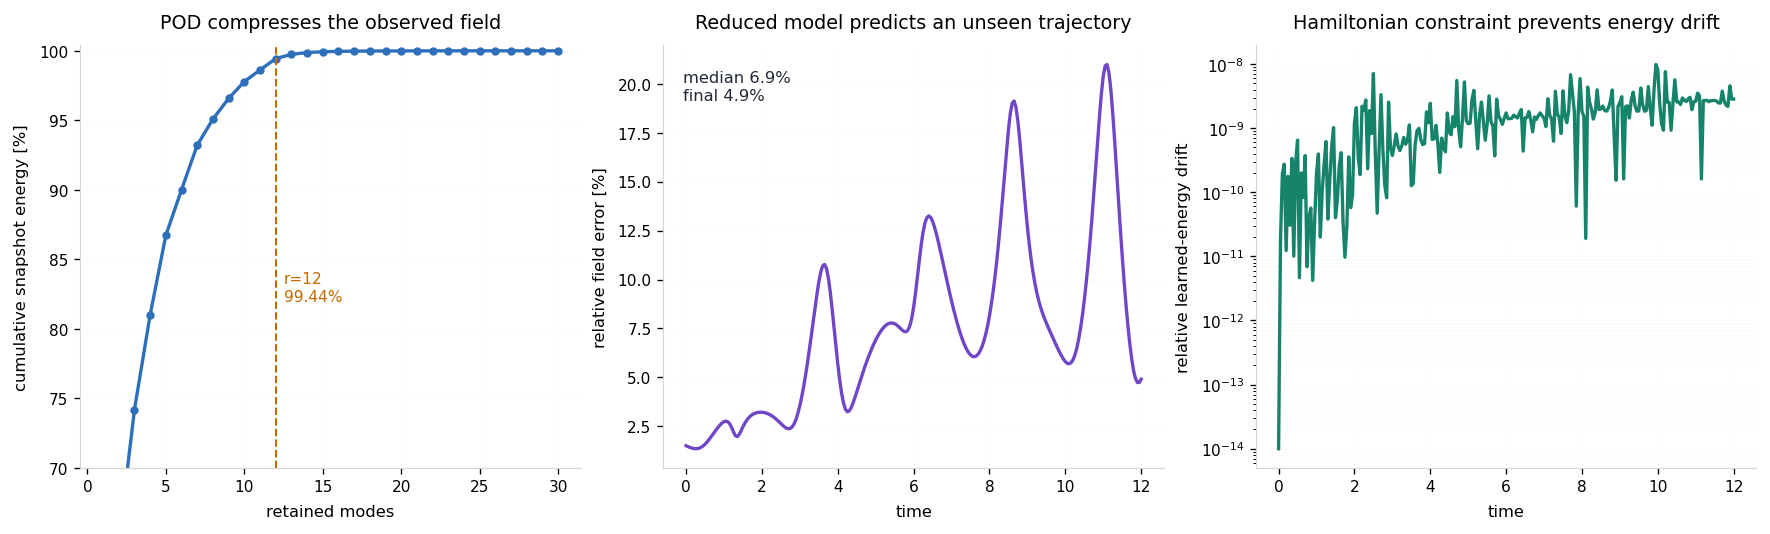

,diagnostic,value
0,POD snapshot energy retained,99.4399%
1,median held-out field error,6.9252%
2,final held-out field error,4.9012%
3,maximum learned-energy drift,0.0000%


In [22]:
# POD basis from field snapshots that were used for fitting, never the held-out trajectory.
ROM_RANK = 12
pod_snapshots = phi_train[:5].reshape(-1, NX)
_, pod_singular_values, pod_Vt = np.linalg.svd(pod_snapshots, full_matrices=False)
pod_basis = pod_Vt[:ROM_RANK].T
pod_cumulative_energy = np.cumsum(pod_singular_values**2) / np.sum(pod_singular_values**2)
rom_energy_fraction = float(pod_cumulative_energy[ROM_RANK-1])

# Map the PySINDy acceleration row [phi, pi, phi^3, pi^3, phi_x, ...].
rom_linear = float(pysindy_acceleration_coef[0])
rom_cubic = float(pysindy_acceleration_coef[2])
rom_laplacian = float(pysindy_acceleration_coef[6])

def rom_acceleration(q):
    field = pod_basis @ q
    acceleration = (rom_linear*field + rom_cubic*field**3
                    + rom_laplacian*spectral_derivative(field, 2))
    return acceleration @ pod_basis

rom_phi_reference = phi_test[0]
rom_pi_reference = pi_test[0]
rom_q_reference = rom_phi_reference @ pod_basis
rom_p_reference = rom_pi_reference @ pod_basis
rom_initial_state = np.concatenate([rom_q_reference[0], rom_p_reference[0]])
rom_solution = solve_ivp(
    lambda current_time, state: np.concatenate([
        state[ROM_RANK:], rom_acceleration(state[:ROM_RANK])
    ]),
    (t_obs[0], t_obs[-1]), rom_initial_state, t_eval=t_obs,
    method="DOP853", rtol=1e-8, atol=1e-10,
)
rom_q = rom_solution.y[:ROM_RANK].T
rom_p = rom_solution.y[ROM_RANK:].T
rom_phi = rom_q @ pod_basis.T
rom_pi = rom_p @ pod_basis.T
rom_field_error = (np.linalg.norm(rom_phi-rom_phi_reference, axis=1)
                   / np.maximum(np.linalg.norm(rom_phi_reference, axis=1), 1e-14))
rom_phi_x = spectral_derivative(rom_phi, 1)
rom_energy = DX*np.sum(
    0.5*rom_pi**2 - 0.5*rom_linear*rom_phi**2
    - 0.25*rom_cubic*rom_phi**4 + 0.5*rom_laplacian*rom_phi_x**2,
    axis=1,
)
rom_energy_drift_curve = np.abs(rom_energy-rom_energy[0]) / abs(rom_energy[0])
rom_energy_drift = float(np.max(rom_energy_drift_curve))
rom_median_field_error = float(np.median(rom_field_error))
rom_final_field_error = float(rom_field_error[-1])

fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.3), constrained_layout=True)
mode_index = np.arange(1, min(30, len(pod_cumulative_energy))+1)
axes[0].plot(mode_index, 100*pod_cumulative_energy[:len(mode_index)], "o-",
             color=COLORS["blue"], markersize=4)
axes[0].axvline(ROM_RANK, color=COLORS["orange"], ls="--", lw=1.2)
axes[0].set(title="POD compresses the observed field", xlabel="retained modes",
            ylabel="cumulative snapshot energy [%]", ylim=(70, 100.4))
axes[0].grid(alpha=0.15)
axes[0].text(ROM_RANK+0.5, 82, f"r={ROM_RANK}\n{rom_energy_fraction:.2%}",
             color=COLORS["orange"], fontsize=9.2)

axes[1].plot(t_obs, 100*rom_field_error, color=COLORS["purple"])
axes[1].set(title="Reduced model predicts an unseen trajectory", xlabel="time",
            ylabel="relative field error [%]")
axes[1].grid(alpha=0.15)
axes[1].text(0.04, 0.94, f"median {rom_median_field_error:.1%}\nfinal {rom_final_field_error:.1%}",
             transform=axes[1].transAxes, va="top", color=COLORS["ink"])

axes[2].semilogy(t_obs, np.maximum(rom_energy_drift_curve, 1e-14),
                 color=COLORS["green"])
axes[2].set(title="Hamiltonian constraint prevents energy drift", xlabel="time",
            ylabel="relative learned-energy drift")
axes[2].grid(alpha=0.15, which="both")
savefig("16_pod_constrained_rom.png")
plt.show()

display(pd.DataFrame({
    "diagnostic": ["POD snapshot energy retained", "median held-out field error",
                   "final held-out field error", "maximum learned-energy drift"],
    "value": [rom_energy_fraction, rom_median_field_error,
              rom_final_field_error, rom_energy_drift],
}).style.format({"value": "{:.4%}"}))

### 11.4 Evidence-first visual synthesis

The next two diagrams follow the rigorous visual logic of the PySINDy —hyperparameter paths, uncertainty, constraints and held-out dynamics—but combine those tests into a cleaner reading sequence. The first figure shows the complete information flow and makes the fit/tune/test ownership explicit. The second exposes model selection, noisy coefficient uncertainty and dynamical validation in one coordinated view.

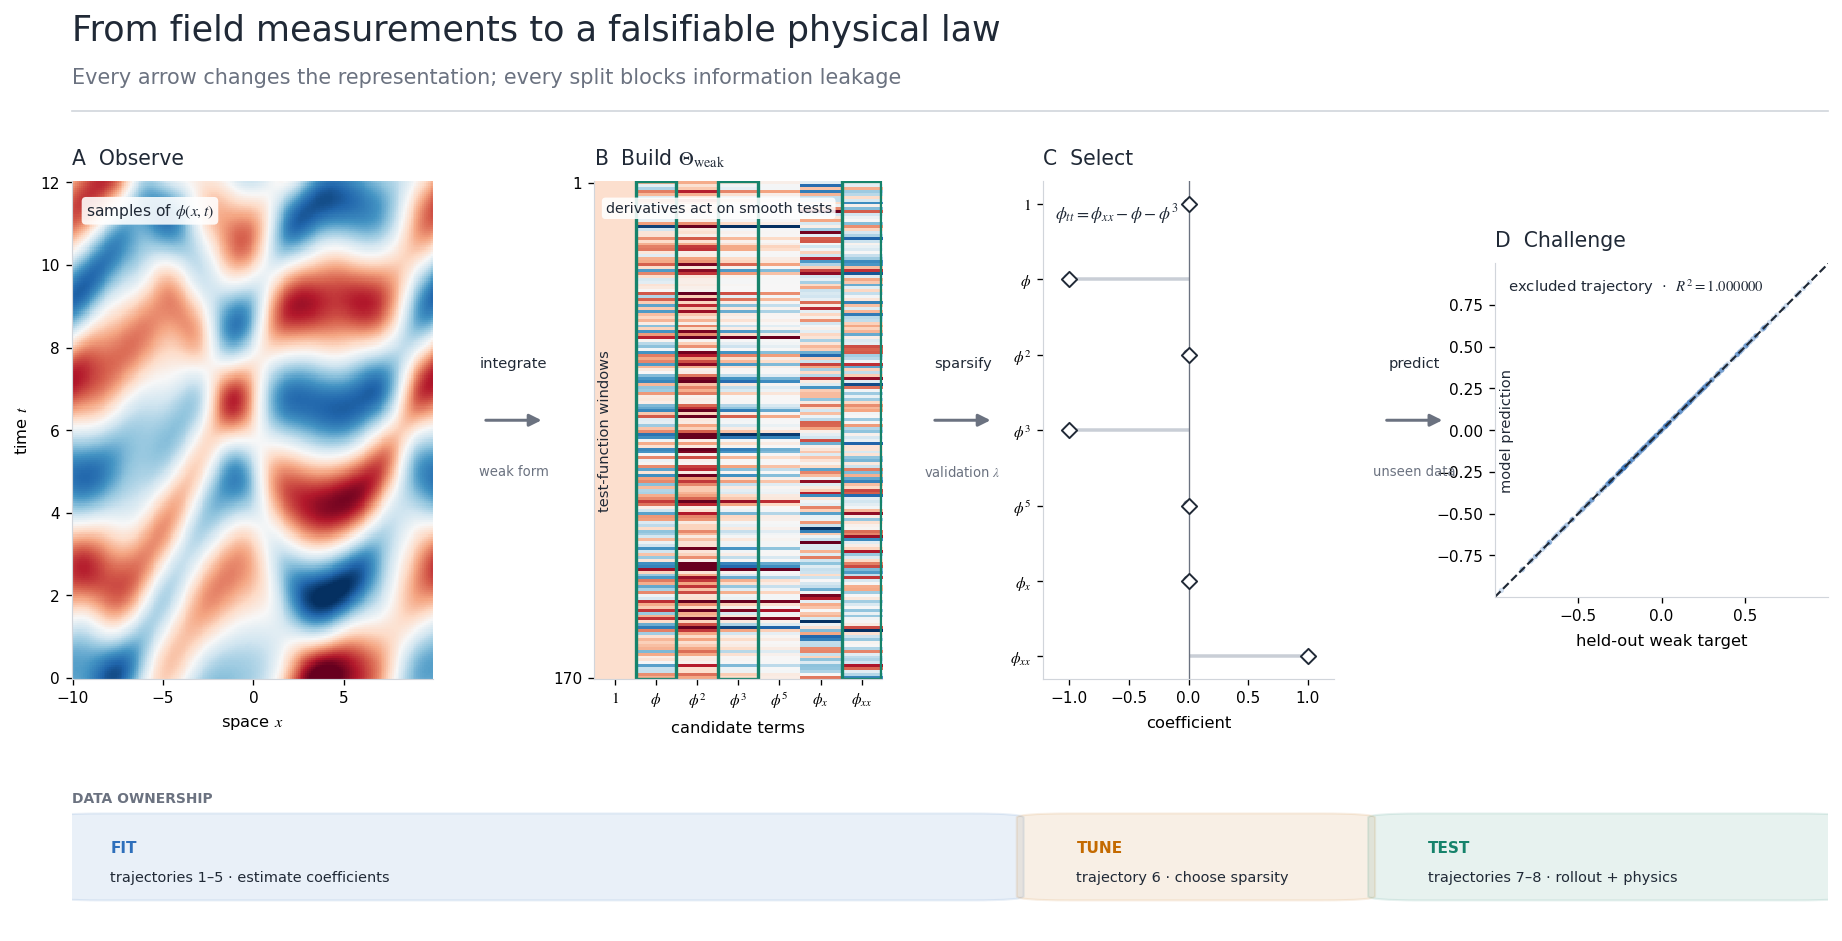

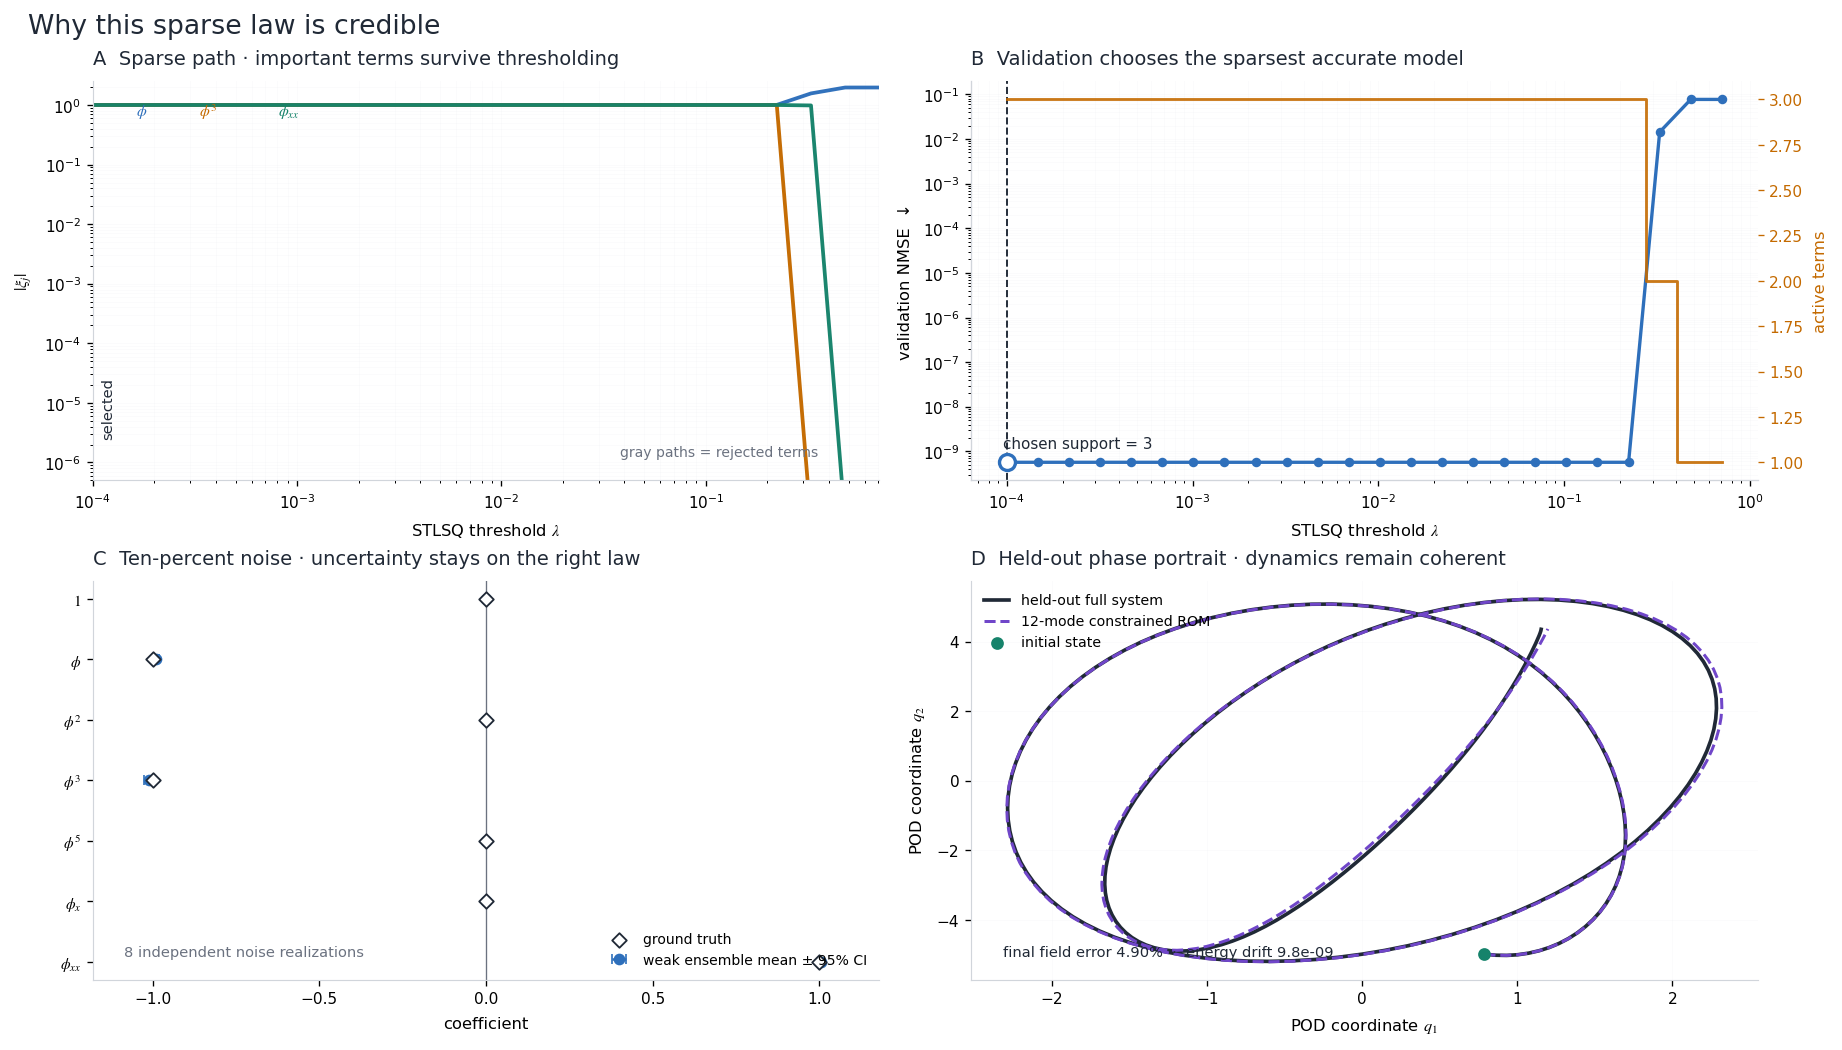

<string>:285: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [23]:
# observation → library → sparse law → excluded-data test.
exec(Path("advanced_topics_visualizations.py").read_text())

## 13. Results dashboard

The dashboard condenses the project into the four messages most useful for a presentation: correct equation structure, weak-form noise robustness, out-of-sample predictive validity and recovery of a Noether charge.

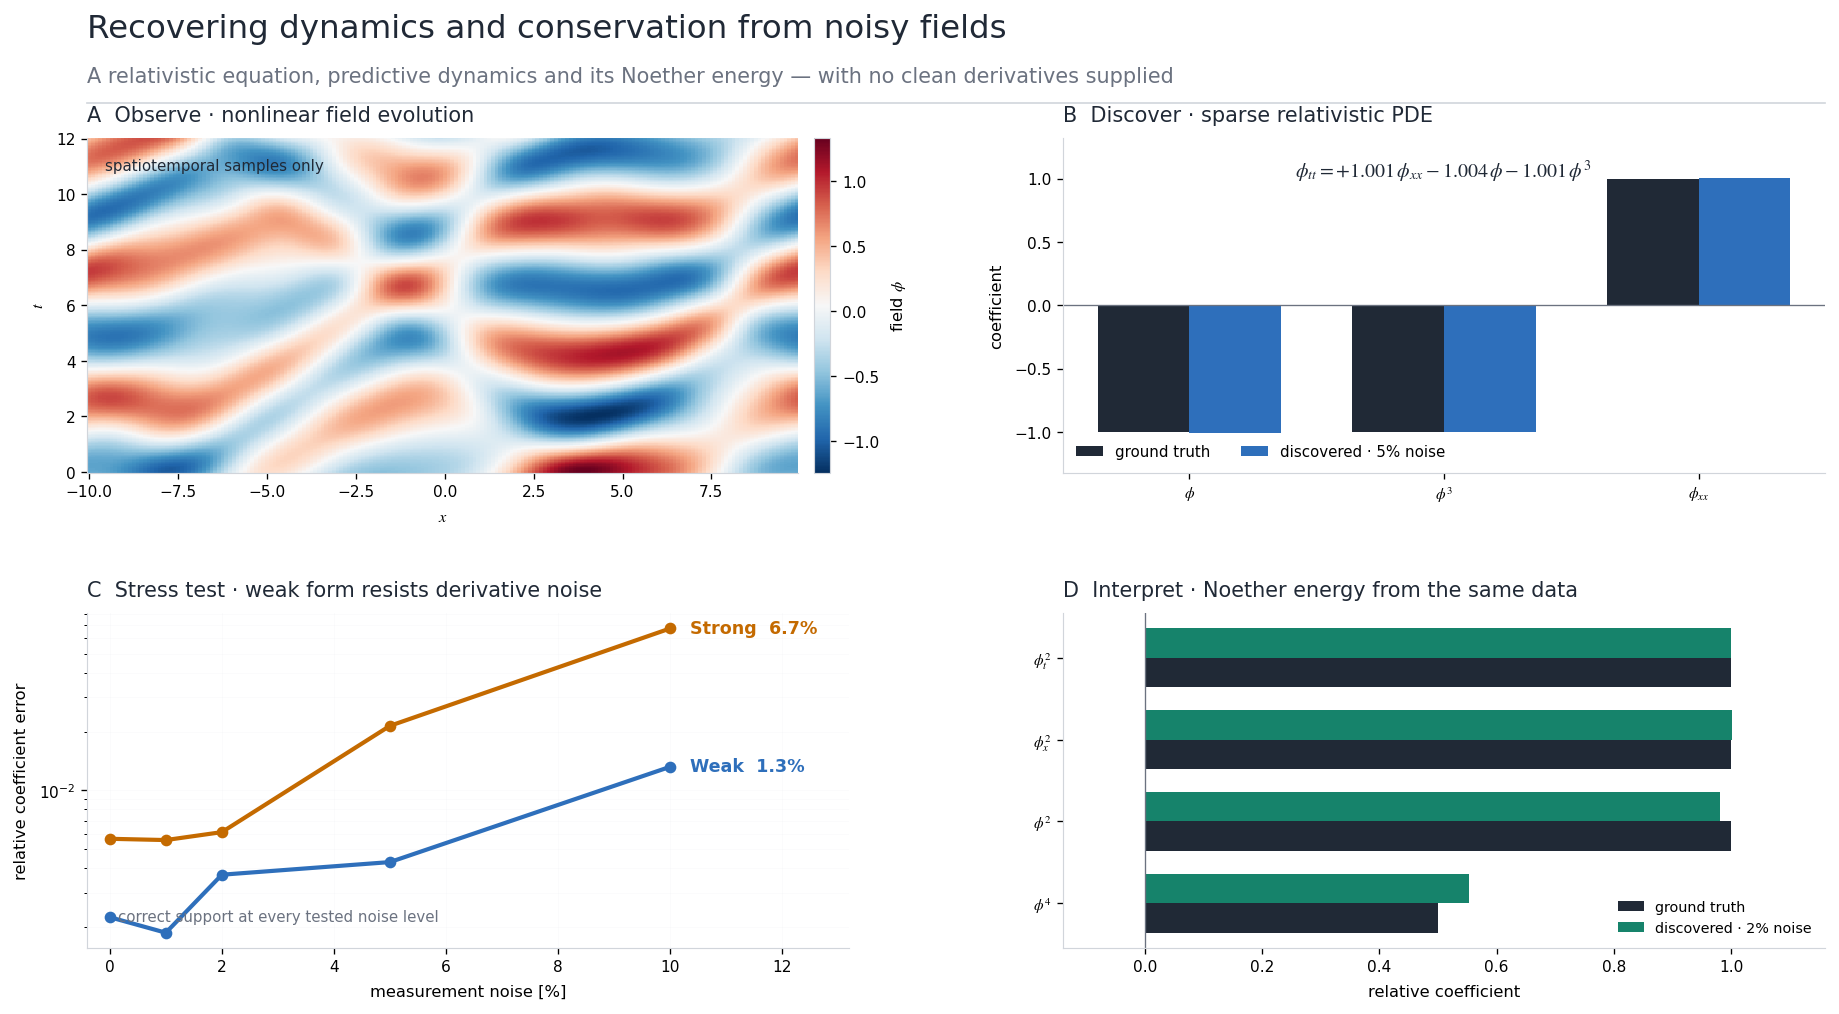

In [25]:
# A 16:9 summary figure designed to work as the final results slide.
coef_5pct = saved_weak_models[0.05]
charge_show = charge_results[(charge_results.noise == 0.02) &
                             (charge_results.repeat == 0)].iloc[0]
e_show = charge_show.energy_coefficients

fig = plt.figure(figsize=(16, 9), facecolor=COLORS["paper"])
gs = fig.add_gridspec(2, 2, left=0.06, right=0.965, bottom=0.07, top=0.82,
                      hspace=0.42, wspace=0.28)
axes = np.array([[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
                 [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])

fig.text(0.06, 0.935, "Recovering dynamics and conservation from noisy fields",
         fontsize=19.5, fontweight="medium", color=COLORS["ink"], va="top")
fig.text(0.06, 0.886,
         "A relativistic equation, predictive dynamics and its Noether energy — with no clean derivatives supplied",
         fontsize=12.5, color=COLORS["gray"], va="top")
fig.add_artist(plt.Line2D([0.06, 0.965], [0.852, 0.852], transform=fig.transFigure,
                          color="#D1D5DB", lw=1.0))

# A — the raw observable.
im = axes[0, 0].pcolormesh(x, t_obs, phi_all[0], shading="auto", cmap="RdBu_r")
axes[0, 0].set(title="A  Observe · nonlinear field evolution", xlabel="$x$", ylabel="$t$")
cb = fig.colorbar(im, ax=axes[0, 0], pad=0.02, fraction=0.047)
cb.set_label(r"field $\phi$")
axes[0, 0].text(0.025, 0.94, "spatiotemporal samples only", transform=axes[0, 0].transAxes,
                ha="left", va="top", fontsize=9.0, color=COLORS["ink"])

# B — sparse support and coefficients.
dashboard_pde_active = np.flatnonzero(np.abs(TRUE_PDE_COEF) > 1e-12)
dashboard_x = np.arange(len(dashboard_pde_active))
axes[0, 1].bar(dashboard_x-0.18, TRUE_PDE_COEF[dashboard_pde_active], 0.36,
               color=COLORS["ink"], label="ground truth")
axes[0, 1].bar(dashboard_x+0.18, coef_5pct[dashboard_pde_active], 0.36,
               color=COLORS["blue"], label="discovered · 5% noise")
axes[0, 1].axhline(0, color=COLORS["gray"], lw=0.8)
axes[0, 1].set_xticks(dashboard_x, np.asarray(PDE_LABELS)[dashboard_pde_active])
axes[0, 1].set(title="B  Discover · sparse relativistic PDE", ylabel="coefficient",
               ylim=(-1.32, 1.32))
equation_label = (rf"$\phi_{{tt}}={coef_5pct[6]:+.3f}\,\phi_{{xx}}"
                  rf"{coef_5pct[1]:+.3f}\,\phi{coef_5pct[3]:+.3f}\,\phi^3$")
axes[0, 1].text(0.50, 0.94, equation_label, transform=axes[0, 1].transAxes,
                ha="center", va="top", fontsize=12, color=COLORS["ink"])
axes[0, 1].legend(loc="lower left", frameon=False, ncol=2, fontsize=9)

# C — robustness, with the difficult 10% case labeled directly.
final_errors = {}
for method in ["Strong", "Weak"]:
    subset = noise_results[noise_results.method == method]
    means = subset.groupby("noise").coefficient_error.mean().reindex(NOISE_LEVELS)
    final_errors[method] = float(means.iloc[-1])
    axes[1, 0].semilogy(100*NOISE_LEVELS, means, "o-", lw=2.5,
                        color=method_colors[method], markersize=6)
    axes[1, 0].text(10.35, means.iloc[-1], f"{method}  {100*means.iloc[-1]:.1f}%",
                    ha="left", va="center", fontsize=10.5,
                    color=method_colors[method], fontweight="bold")
axes[1, 0].set(title="C  Stress test · weak form resists derivative noise",
               xlabel="measurement noise [%]", ylabel="relative coefficient error",
               xlim=(-0.4, 13.2))
axes[1, 0].grid(alpha=0.16, which="both")
axes[1, 0].text(0.04, 0.08, "correct support at every tested noise level",
                transform=axes[1, 0].transAxes, fontsize=9.0, color=COLORS["gray"])

# D — the Noether energy recovered from the same measurements.
charge_labels = np.array([r"$\phi_t^2$", r"$\phi_x^2$", r"$\phi^2$", r"$\phi^4$",
                          r"$\phi^6$", r"$\phi_t\phi_x$", r"$\phi\phi_t$", r"$\phi_x^4$"])
dashboard_charge_active = np.flatnonzero(np.abs(TRUE_ENERGY_COEF) > 1e-12)
y_charge = np.arange(len(dashboard_charge_active))
axes[1, 1].barh(y_charge+0.18, TRUE_ENERGY_COEF[dashboard_charge_active], 0.36,
                color=COLORS["ink"], label="ground truth")
axes[1, 1].barh(y_charge-0.18, e_show[dashboard_charge_active], 0.36,
                color=COLORS["green"], label="discovered · 2% noise")
axes[1, 1].set_yticks(y_charge, charge_labels[dashboard_charge_active])
axes[1, 1].invert_yaxis()
axes[1, 1].set(title="D  Interpret · Noether energy from the same data",
               xlabel="relative coefficient", xlim=(-0.14, 1.16))
axes[1, 1].axvline(0, color=COLORS["gray"], lw=0.8)
axes[1, 1].legend(loc="lower right", frameon=False, fontsize=8.6)

for ax in axes.ravel():
    ax.set_facecolor("white")
    ax.title.set_fontsize(12.5)
    ax.title.set_fontweight("medium")
    ax.title.set_color(COLORS["ink"])
    ax.title.set_position((0.0, 1.02))
    ax.title.set_ha("left")
    ax.spines[["top", "right"]].set_visible(False)

savefig("08_results_dashboard.png")
plt.show()

## 14. Conclusions

### What the experiment demonstrates

- A sparse candidate library can identify an interpretable relativistic field equation from spatiotemporal measurements.
- Direct differentiation is the principal noise bottleneck; transferring derivatives to compact test functions produces a substantially more robust inverse problem.
- Predictive rollout on a new initial condition provides a stronger validation than regression residual alone.
- The same field observations contain information about invariant structure: an approximate null space reveals energy and momentum, and sparsity separates the physically meaningful charges.
- A second weak sparse calculation recovers the corresponding **local density–flux pairs** and validates the continuity equations on an unseen spacetime trajectory; this is stronger than checking global charges alone.
- The correct PDE also survives an independent finite-difference/adaptive-Runge–Kutta generator, sensor averaging, correlated noise and missing data, ruling out the most obvious shared-solver inverse crime.
- A genuine PySINDy model independently recovers the same first-order field system, providing a maintained-software cross-check of the custom sparse solver.
- Symmetry constraints, TV preprocessing and compressed weak regression quantify how physical priors and limited samples affect identifiability instead of assuming that each method must help.
- A 12-mode POD–Galerkin model built from the discovered PDE predicts a held-out trajectory while conserving its learned Hamiltonian to numerical precision.




## References

1. S. L. Brunton, J. L. Proctor and J. N. Kutz, “Discovering governing equations from data by sparse identification of nonlinear dynamical systems,” *PNAS* **113**, 3932–3937 (2016). [doi:10.1073/pnas.1517384113](https://doi.org/10.1073/pnas.1517384113)
2. S. H. Rudy, S. L. Brunton, J. L. Proctor and J. N. Kutz, “Data-driven discovery of partial differential equations,” *Science Advances* **3**, e1602614 (2017). [doi:10.1126/sciadv.1602614](https://doi.org/10.1126/sciadv.1602614)
3. D. A. Messenger and D. M. Bortz, “Weak SINDy for partial differential equations,” *Journal of Computational Physics* **443**, 110525 (2021). [doi:10.1016/j.jcp.2021.110525](https://doi.org/10.1016/j.jcp.2021.110525)
4. N. Byers, “E. Noether's discovery of the deep connection between symmetries and conservation laws,” in *The Heritage of Emmy Noether* (1999). [arXiv:physics/9807044](https://arxiv.org/abs/physics/9807044)
5. F. Alet et al., “Noether Networks: Meta-Learning Useful Conserved Quantities,” *NeurIPS* **34** (2021). [paper](https://proceedings.neurips.cc/paper/2021/hash/886ad506e0c115cf590d18ebb6c26561-Abstract.html)
6. P. Virtanen et al., “SciPy 1.0: fundamental algorithms for scientific computing in Python,” *Nature Methods* **17**, 261–272 (2020). [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)
7. B. M. de Silva et al., “PySINDy: A Python package for the sparse identification of nonlinear dynamical systems from data,” *Journal of Open Source Software* **5**, 2104 (2020). [doi:10.21105/joss.02104](https://doi.org/10.21105/joss.02104)
8. Y. Guan, S. L. Brunton and I. Novosselov, “Sparse nonlinear models of chaotic electroconvection,” *Royal Society Open Science* **8**, 202367 (2021). [doi:10.1098/rsos.202367](https://doi.org/10.1098/rsos.202367)
9. J.-C. Loiseau and S. L. Brunton, “Constrained sparse Galerkin regression,” *Journal of Fluid Mechanics* **838**, 42–67 (2018). [doi:10.1017/jfm.2017.823](https://doi.org/10.1017/jfm.2017.823)
10. L. I. Rudin, S. Osher and E. Fatemi, “Nonlinear total variation based noise removal algorithms,” *Physica D* **60**, 259–268 (1992). [doi:10.1016/0167-2789(92)90242-F](https://doi.org/10.1016/0167-2789(92)90242-F)



In [41]:
# Compact reproducibility report
report = pd.DataFrame({
    "quantity": [
        "random seed", "spatial points", "observation times", "training trajectories",
        "held-out trajectories", "solver step", "observation step", "saved figures"
    ],
    "value": [
        SEED, NX, len(t_obs), len(phi_train), len(phi_test), DT_SOLVER, DT_OBS,
        len(list(FIG_DIR.glob("*.png")))
    ]
})
display(report)

,quantity,value
0,random seed,314159.00
1,spatial points,192.00
2,observation times,241.00
3,training trajectories,6.00
4,held-out trajectories,2.00
5,solver step,0.01
6,observation step,0.05
7,saved figures,23.00
